Check input, variable names, variable range and mean

In [ ]:
# ============================================================
# Inspect processed_simvp_data.npz
# - Lists NPZ keys
# - For X, Y, Mask: prints shape/dtype
# - Computes (NaN-aware) min/max/mean/std + NaN% for each channel
#   * X: per-variable channel stats (C_in channels)
#   * Y: per-pollutant channel stats (6 channels)
#   * Mask: unique values + fraction of valid pixels
# - Uses streaming over time to avoid OOM
# ============================================================

import os
import numpy as np
from google.colab import drive

print("Mounting Google Drive...")
drive.mount("/content/drive")

# -------------------------
# EDIT THIS PATH if needed
# -------------------------
NPZ_PATH = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
assert os.path.exists(NPZ_PATH), f"❌ Not found: {NPZ_PATH}"
print("✅ Found:", NPZ_PATH, "| size (GB):", os.path.getsize(NPZ_PATH)/1e9)

# If you know your Y channel order, set it here:
# From your xarray pollution file it looked like:
# CO, NO2, O3, PM10, PM25, SO2
TARGET_NAMES = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ---- Load NPZ (lazy until indexed) ----
data = np.load(NPZ_PATH, allow_pickle=False)
print("\nNPZ keys:", list(data.files))

def print_array_info(name):
    arr = data[name]
    print(f"\n[{name}] shape={arr.shape} dtype={arr.dtype}")
    return arr

X = print_array_info("X")
Y = print_array_info("Y")
M = print_array_info("Mask")

# ------------------------------------------------------------
# Streaming stats helpers (NaN-aware)
# ------------------------------------------------------------
def init_stats(C):
    return {
        "count": np.zeros(C, dtype=np.float64),      # non-NaN count
        "nan_count": np.zeros(C, dtype=np.float64),
        "sum": np.zeros(C, dtype=np.float64),
        "sumsq": np.zeros(C, dtype=np.float64),
        "min": np.full(C, np.inf, dtype=np.float64),
        "max": np.full(C, -np.inf, dtype=np.float64),
    }

def update_stats(stats, chunk):
    """
    chunk expected shape: (T, C, H, W)
    """
    c = chunk.astype(np.float64, copy=False)
    T, C, H, W = c.shape
    c2 = c.reshape(T, C, -1)

    is_nan = np.isnan(c2)
    nan_count = is_nan.sum(axis=(0,2))
    valid = ~is_nan

    cnt = valid.sum(axis=(0,2))

    c2_0 = np.where(valid, c2, 0.0)
    s  = c2_0.sum(axis=(0,2))
    ss = (c2_0 * c2_0).sum(axis=(0,2))

    c_min = np.where(valid, c2, np.inf).min(axis=(0,2))
    c_max = np.where(valid, c2, -np.inf).max(axis=(0,2))

    stats["count"] += cnt
    stats["nan_count"] += nan_count
    stats["sum"] += s
    stats["sumsq"] += ss
    stats["min"] = np.minimum(stats["min"], c_min)
    stats["max"] = np.maximum(stats["max"], c_max)

def finalize_stats(stats):
    eps = 1e-12
    mean = stats["sum"] / (stats["count"] + eps)
    var = stats["sumsq"] / (stats["count"] + eps) - mean**2
    var = np.maximum(var, 0.0)
    std = np.sqrt(var)
    nan_pct = stats["nan_count"] / (stats["nan_count"] + stats["count"] + eps) * 100.0
    return mean, std, stats["min"], stats["max"], nan_pct, stats["count"]

# ------------------------------------------------------------
# Compute stats for X and Y in chunks over time
# ------------------------------------------------------------
def compute_channel_stats(arr, name, chunk_T=32):
    """
    arr shape: (T, C, H, W)
    """
    T, C, H, W = arr.shape
    stats = init_stats(C)
    print(f"\nComputing stats for {name}: T={T}, C={C}, H={H}, W={W}, chunk_T={chunk_T}")
    for t0 in range(0, T, chunk_T):
        t1 = min(T, t0 + chunk_T)
        chunk = arr[t0:t1]
        update_stats(stats, chunk)
        if (t0 // chunk_T) % 10 == 0:
            print(f"  processed {t1}/{T} time steps...")
    mean, std, vmin, vmax, nan_pct, count = finalize_stats(stats)
    return {"mean": mean, "std": std, "min": vmin, "max": vmax, "nan_pct": nan_pct, "count": count}

X_stats = compute_channel_stats(X, "X", chunk_T=16)
Y_stats = compute_channel_stats(Y, "Y", chunk_T=32)

# ------------------------------------------------------------
# Mask summary (unique values + valid fraction)
# ------------------------------------------------------------
def mask_summary(M, chunk_T=64):
    T = M.shape[0]
    print(f"\nComputing Mask summary: shape={M.shape}")
    uniq = set()
    valid_cnt = 0
    total_cnt = 0
    for t0 in range(0, T, chunk_T):
        t1 = min(T, t0 + chunk_T)
        chunk = M[t0:t1]
        u = np.unique(chunk)
        for x in u[:100]:
            uniq.add(float(x))
        valid_cnt += np.sum(chunk >= 0.5)
        total_cnt += chunk.size
    uniq = sorted(list(uniq))
    return uniq, valid_cnt / (total_cnt + 1e-12)

mask_uniq, mask_valid_frac = mask_summary(M)

# ------------------------------------------------------------
# Pretty print results
# ------------------------------------------------------------
print("\n==================== SUMMARY ====================")

print("\n[Mask]")
print("  Unique values (sampled):", mask_uniq[:20], ("..." if len(mask_uniq) > 20 else ""))
print(f"  Valid fraction (mask>=0.5): {mask_valid_frac*100:.2f}%")

print("\n[X] Per-channel stats (C_in channels):")
for c in range(X.shape[1]):
    print(f"  X[{c:02d}]  mean={X_stats['mean'][c]: .6f}  std={X_stats['std'][c]: .6f}  "
          f"min={X_stats['min'][c]: .6f}  max={X_stats['max'][c]: .6f}  "
          f"NaN%={X_stats['nan_pct'][c]: .3f}%  count={int(X_stats['count'][c])}")

print("\n[Y] Per-channel stats (pollutants):")
for c in range(Y.shape[1]):
    nm = TARGET_NAMES[c] if c < len(TARGET_NAMES) else f"Y{c}"
    print(f"  {nm:>6s}  mean={Y_stats['mean'][c]: .6f}  std={Y_stats['std'][c]: .6f}  "
          f"min={Y_stats['min'][c]: .6f}  max={Y_stats['max'][c]: .6f}  "
          f"NaN%={Y_stats['nan_pct'][c]: .3f}%  count={int(Y_stats['count'][c])}")

print("\n✅ Done.")



Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found: /content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz | size (GB): 4.01102302

NPZ keys: ['X', 'Y', 'Mask']

[X] shape=(5108, 32, 88, 120) dtype=float32

[Y] shape=(5108, 6, 88, 120) dtype=float32

[Mask] shape=(5108, 6, 88, 120) dtype=float32

Computing stats for X: T=5108, C=32, H=88, W=120, chunk_T=16
  processed 16/5108 time steps...
  processed 176/5108 time steps...
  processed 336/5108 time steps...
  processed 496/5108 time steps...
  processed 656/5108 time steps...
  processed 816/5108 time steps...
  processed 976/5108 time steps...
  processed 1136/5108 time steps...
  processed 1296/5108 time steps...
  processed 1456/5108 time steps...
  processed 1616/5108 time steps...
  processed 1776/5108 time steps...
  processed 1936/5108 time steps...
  processed 2096/5108 time steps...
  process

join with the nc file to figure out the header

In [ ]:
# ============================================================
# Build X channel name mapping by reading source .nc headers
# Assumes you built X by concatenating:
#   [ERA5 vars] + [TRAFFIC vars] + [FIRE vars] + [SMOKE vars] + [POLLUTION vars]
# If your stacking order differs, change the ORDER list below.
# ============================================================

import os, json
import numpy as np
import xarray as xr
from google.colab import drive

print("Mounting Google Drive...")
drive.mount("/content/drive")

# -------------------------
# EDIT THESE PATHS
# -------------------------
NPZ_PATH = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"

ERA5_NC     = "/content/drive/MyDrive/graphcast_project/Training Data/era5_california_2022_2025_WIDE_FULL.nc"
TRAFFIC_NC  = "/content/drive/MyDrive/graphcast_project/Training Data/traffic_california_2022_2025_utc_binned_gemini_with_boundary.nc"
FIRE_NC     = "/content/drive/MyDrive/graphcast_project/Training Data/hms_western_us_fire_2022_2025.nc"
SMOKE_NC    = "/content/drive/MyDrive/graphcast_project/Training Data/hms_western_us_smoke_2022_2025.nc"
POLL_NC     = "/content/drive/MyDrive/graphcast_project/Training Data/pollution_la_2022_to_2025_avg_gemini.nc"  # or your wide pollution file

OUT_JSON = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_feature_names.json"

assert os.path.exists(NPZ_PATH), f"❌ Missing NPZ: {NPZ_PATH}"

# -------------------------
# Load NPZ shapes
# -------------------------
npz = np.load(NPZ_PATH)
X = npz["X"]
C_in = X.shape[1]
print("NPZ X shape:", X.shape, "=> C_in =", C_in)

# -------------------------
# Helper: open nc and list variables (metadata only)
# -------------------------
def list_nc_vars(path, prefix):
    assert os.path.exists(path), f"❌ Missing file: {path}"
    ds = xr.open_dataset(path, decode_times=False)  # decode_times=False speeds header read
    vars_ = list(ds.data_vars)
    ds.close()
    # prefix them so you know the source later
    return [f"{prefix}:{v}" for v in vars_], vars_

sources = [
    ("era5", ERA5_NC),
    ("traffic", TRAFFIC_NC),
    ("fire", FIRE_NC),
    ("smoke", SMOKE_NC),
    ("pollution", POLL_NC),
]

all_feature_names = []
raw_lists = {}

print("\n=== Variables per source (.nc header) ===")
for prefix, path in sources:
    fullnames, varlist = list_nc_vars(path, prefix)
    raw_lists[prefix] = varlist
    print(f"\n[{prefix}] {os.path.basename(path)}")
    print("count =", len(varlist))
    print(varlist)
    all_feature_names.extend(fullnames)

print("\n=== Combined feature list ===")
print("Total features from .nc lists:", len(all_feature_names))
print("NPZ C_in:", C_in)

if len(all_feature_names) != C_in:
    print("\n⚠️ COUNT MISMATCH.")
    print("This means at least one of these is true:")
    print("1) You did NOT stack all vars from each .nc (you selected/reordered some).")
    print("2) You stacked in a different order than [era5, traffic, fire, smoke, pollution].")
    print("3) You added extra static channels (lat/lon masks/boundary/etc) not present as data_vars.")
    print("4) Your pollution .nc is not the same one used to build the NPZ.")
    print("\nNext step: tell me what files you used to build X, or show the preprocessing stacking code.")
else:
    print("\n✅ COUNT MATCH. Mapping can be created.")

    # Print channel mapping
    print("\n=== X channel index -> feature name ===")
    for i, name in enumerate(all_feature_names):
        print(f"X[{i:02d}] = {name}")

    # Save mapping to JSON for reuse in training/testing
    payload = {
        "npz_path": NPZ_PATH,
        "C_in": int(C_in),
        "feature_names": all_feature_names,
        "source_vars": raw_lists
    }
    with open(OUT_JSON, "w") as f:
        json.dump(payload, f, indent=2)

    print("\n✅ Saved mapping JSON to:", OUT_JSON)
    print("You can load it later with:")
    print(f"  import json; names=json.load(open('{OUT_JSON}'))['feature_names']")


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NPZ X shape: (5108, 32, 88, 120) => C_in = 32

=== Variables per source (.nc header) ===

[era5] era5_california_2022_2025_WIDE_FULL.nc
count = 20
['u10', 'v10', 'd2m', 't2m', 'msl', 'tp', 'tcrw', 'blh', 't2m_c', 'd2m_c', 'rh', 'msl_hpa', 'z_70000', 'z_85000', 't_70000', 't_85000', 'u_70000', 'u_85000', 'v_70000', 'v_85000']

[traffic] traffic_california_2022_2025_utc_binned_gemini_with_boundary.nc
count = 3
['traffic_flow', 'traffic_occupancy', 'traffic_speed']

[fire] hms_western_us_fire_2022_2025.nc
count = 2
['fire_presence', 'fire_intensity']

[smoke] hms_western_us_smoke_2022_2025.nc
count = 1
['smoke_density']

[pollution] pollution_la_2022_to_2025_avg_gemini.nc
count = 6
['CO_concentration', 'NO2_concentration', 'O3_concentration', 'PM10_concentration', 'PM25_concentration', 'SO2_concentration']

=== Combined feature list ===


First check output
<xarray.Dataset> Size: 3GB
Dimensions:             (time: 5108, lat: 88, lon: 120)
Coordinates:
  * time                (time) datetime64[ns] 41kB 2022-01-01 ... 2025-06-30T...
  * lat                 (lat) float64 704B 28.0 28.25 28.5 ... 49.25 49.5 49.75
  * lon                 (lon) float64 960B -135.0 -134.8 ... -105.5 -105.2
Data variables:
    CO_concentration    (time, lat, lon) float64 432MB ...
    NO2_concentration   (time, lat, lon) float64 432MB ...
    O3_concentration    (time, lat, lon) float64 432MB ...
    PM10_concentration  (time, lat, lon) float64 432MB ...
    PM25_concentration  (time, lat, lon) float64 432MB ...
    SO2_concentration   (time, lat, lon) float64 432MB ...

In [ ]:
import xarray as xr

nc_path = "/content/drive/MyDrive/graphcast_project/Training Data/pollution_la_2022_to_2025_avg_gemini.nc"

ds = xr.open_dataset(nc_path)

print(ds)


<xarray.Dataset> Size: 3GB
Dimensions:             (time: 5108, lat: 88, lon: 120)
Coordinates:
  * time                (time) datetime64[ns] 41kB 2022-01-01 ... 2025-06-30T...
  * lat                 (lat) float64 704B 28.0 28.25 28.5 ... 49.25 49.5 49.75
  * lon                 (lon) float64 960B -135.0 -134.8 ... -105.5 -105.2
Data variables:
    CO_concentration    (time, lat, lon) float64 432MB ...
    NO2_concentration   (time, lat, lon) float64 432MB ...
    O3_concentration    (time, lat, lon) float64 432MB ...
    PM10_concentration  (time, lat, lon) float64 432MB ...
    PM25_concentration  (time, lat, lon) float64 432MB ...
    SO2_concentration   (time, lat, lon) float64 432MB ...


Check how many pollutions (6)

In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz')
Y = data['Y']

print("Y shape:", Y.shape)
print("Channel count:", Y.shape[1])

Y shape: (5108, 6, 88, 120)
Channel count: 6


use statistical fingerprints to figure out the pollution sequence

In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz')
Y = data['Y']

pollutant_stats = []
for c in range(Y.shape[1]):
    vals = Y[:, c, :, :].reshape(-1)
    vals = vals[np.isfinite(vals)]
    pollutant_stats.append({
        "channel": c,
        "mean": float(np.mean(vals)),
        "p95": float(np.percentile(vals, 95)),
        "max": float(np.max(vals))
    })

for s in pollutant_stats:
    print(s)


{'channel': 0, 'mean': 0.0018801696132868528, 'p95': 0.006227621342986822, 'max': 0.019510067999362946}
{'channel': 1, 'mean': 0.020395994186401367, 'p95': 0.09176796674728394, 'max': 0.9088788628578186}
{'channel': 2, 'mean': 0.009036418050527573, 'p95': 0.038201428949832916, 'max': 0.23428520560264587}
{'channel': 3, 'mean': 0.08653340488672256, 'p95': 0.3447541892528534, 'max': 0.551897406578064}
{'channel': 4, 'mean': 0.14090871810913086, 'p95': 0.46612548828125, 'max': 0.9999998807907104}
{'channel': 5, 'mean': 0.09801039099693298, 'p95': 0.32912373542785645, 'max': 0.865485429763794}


Gemini version

version 1 with peak capture ration 40%.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,        # 48 hours (8 steps)
    'Horizon': 1,        # 6 hours ahead
    'Batch_Size': 16,
    'Hid_S': 128,        # Hidden channels
    'Hid_T': 256,        # Translator channels
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Check for GPU
if CONFIG['Device'] == 'cpu':
    print("⚠️ WARNING: You are running on CPU! Go to 'Runtime > Change runtime type' and select GPU.")

# ==========================
# 2. DATASET
# ==========================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Flatten Time into Channels
        # Input shape: (8, Num_Vars, H, W) -> (8 * Num_Vars, H, W)
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        y_target = self.Y[i + CONFIG['History']]
        mask = self.M[i + CONFIG['History']]

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())

# ==========================
# 3. SIMVP MODEL
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2) if transpose else nn.Conv2d(in_c, out_c, k, s, p)
        self.norm = nn.GroupNorm(2, out_c)
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.mid(x)
        y = self.dec(x)
        return y

class MaskedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.L1Loss(reduction='none')

    def forward(self, pred, target, mask):
        raw_loss = self.loss_fn(pred, target)
        masked_loss = raw_loss * mask
        return masked_loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 4. EXECUTION LOOP
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data (Once to save RAM)...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    # --- FIX START: DYNAMIC CHANNEL DETECTION ---
    # We read the number of variables directly from the data shape
    # X_full shape is (Time, Variables, H, W)
    num_vars = X_full.shape[1]

    # Calculate Input Channels: (Variables * History Steps)
    in_dim = num_vars * CONFIG['History']
    out_dim = 6 # Pollution variables

    print(f"✅ Detected {num_vars} variables per time step.")
    print(f"✅ Model Input Channels: {in_dim} ({num_vars} vars * {CONFIG['History']} steps)")
    # --- FIX END ---

    # Chronological Split
    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon']
    train_idx_end = int(total_len * 0.85)

    train_indices = range(0, train_idx_end)
    val_indices = range(train_idx_end, total_len)

    # Create Datasets
    train_ds = PollutionDataset(X_full, Y_full, M_full, train_indices)
    val_ds   = PollutionDataset(X_full, Y_full, M_full, val_indices)

    # Loaders
    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print(f"Data Loaded: {len(train_ds)} Train, {len(val_ds)} Val samples.")

    # Initialize Model with CORRECT Dimensions
    print(f"🚀 Training on {CONFIG['Device']} (Please ensure this says 'cuda'!)")
    model = SimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG['Device'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])
    criterion = MaskedLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        # --- TRAIN ---
        model.train()
        train_loss = 0
        for x, y, mask in train_loader:
            x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y, mask)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        # --- VALIDATE ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask in val_loader:
                x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)

        # Scheduler & Checkpoint
        scheduler.step(avg_val)
        current_lr = optimizer.param_groups[0]['lr']

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/Jan_best_simvp_48h_v1.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {current_lr:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ processed_simvp_data.npz not found.")

Mounting Google Drive...
Mounted at /content/drive
>>> Loading Data (Once to save RAM)...
✅ Detected 32 variables per time step.
✅ Model Input Channels: 256 (32 vars * 8 steps)
Data Loaded: 4334 Train, 765 Val samples.
🚀 Training on cuda (Please ensure this says 'cuda'!)

>>> STARTING TRAINING
Epoch 01 | Train: 0.04886 | Val: 0.04267 | LR: 1.0e-03 💾 Saved Best
Epoch 02 | Train: 0.04218 | Val: 0.03836 | LR: 1.0e-03 💾 Saved Best
Epoch 03 | Train: 0.03733 | Val: 0.03626 | LR: 1.0e-03 💾 Saved Best
Epoch 04 | Train: 0.03427 | Val: 0.03459 | LR: 1.0e-03 💾 Saved Best
Epoch 05 | Train: 0.03206 | Val: 0.03267 | LR: 1.0e-03 💾 Saved Best
Epoch 06 | Train: 0.03058 | Val: 0.03172 | LR: 1.0e-03 💾 Saved Best
Epoch 07 | Train: 0.02968 | Val: 0.03203 | LR: 1.0e-03 
Epoch 08 | Train: 0.02931 | Val: 0.03117 | LR: 1.0e-03 💾 Saved Best
Epoch 09 | Train: 0.02868 | Val: 0.03248 | LR: 1.0e-03 
Epoch 10 | Train: 0.02809 | Val: 0.03055 | LR: 1.0e-03 💾 Saved Best
Epoch 11 | Train: 0.02762 | Val: 0.03113 | LR: 1.

gemini improved version (being improved). Try to penalize the peak loss to capture the jump

This is a classic "Engineering Trade-off" in image generation. You are absolutely correct to flag this.The Diagnosis: Why it dropped (40% $\rightarrow$ 25%)The drop happened because of the "Upsample Fix" (replacing ConvTranspose2d with Upsample) I provided in the previous step.Old Version (ConvTranspose2d): This layer acts like a Fine-Point Pen. It has "learnable weights" that can draw sharp, single-pixel spikes (fires).Current Version (Upsample): This layer acts like a Blur Tool. It mathematically smooths the pixels to remove the grid artifacts. In doing so, it "sanded down" the sharp peak of the fire, turning a bright red spot into a dull pink blob.The Solution: "The Hunter" ConfigurationTo get that number from 25% (or your previous 40%) up to 60-80%, we need to change the model's psychology. Right now, it plays it safe to minimize average error. We need to tell it: "I don't care about the average. I want the Peaks."We will do this with two changes:Revert the Decoder: Go back to ConvTranspose2d. We will accept the faint checkerboard artifacts because we need the Sharpness to hit the high peaks.Add "Weighted" Loss: Currently, the model treats a 10% error in the ocean the same as a 10% error in a fire. We will change the math to say: "If the pollution is high, the error counts 5x more."Here is the complete, corrected code.What to Expect:Your Training/Validation Loss will appear higher (e.g., 0.10 instead of 0.04) because we are now multiplying errors by 5. This is normal.The Capture Ratio on the Jan 2025 fire should jump significantly.

However this version has the following for stressed test. not as good as the original version, which is capture ratio 40%

True Spike Amplitude: 0.5783

Predicted Spike Amplitude: 0.1877

Capture Ratio: 32.5%

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
# drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,        # 48 hours
    'Horizon': 1,        # 6 hours ahead
    'Batch_Size': 16,
    'Hid_S': 128,
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Peak_Weight': 5.0,  # NEW: High values are 5x more important
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ==========================
# 2. DATASET (Standard)
# ==========================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        target_idx = i + CONFIG['History'] + CONFIG['Horizon'] - 1
        y_target = self.Y[target_idx]
        mask = self.M[target_idx]

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())

# ==========================
# 3. SIMVP MODEL (REVERTED TO SHARP DECODER)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()

        # Keep GroupNorm (Safety)
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)

        # --- CHANGED: BACK TO TRANSPOSE CONV ---
        # We accept minor artifacts to gain Peak Accuracy (Sharpness)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.mid(x)
        y = self.dec(x)
        return y

# ==========================
# 4. WEIGHTED LOSS (THE FIX FOR PEAKS)
# ==========================
class WeightedL1Loss(nn.Module):
    def __init__(self, peak_weight=5.0):
        super().__init__()
        self.peak_weight = peak_weight
        self.base_loss = nn.L1Loss(reduction='none')

    def forward(self, pred, target, mask):
        # 1. Base Error
        raw_loss = self.base_loss(pred, target)

        # 2. Importance Map
        # If Target=0.0 (Clean), Weight=1.0
        # If Target=1.0 (Fire),  Weight=5.0 (Configurable)
        # Formula: 1 + (target * (max_weight - 1))
        importance_map = 1.0 + (target * (self.peak_weight - 1.0))

        # 3. Apply
        weighted_loss = raw_loss * importance_map * mask
        return weighted_loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION LOOP
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    num_vars = X_full.shape[1]
    in_dim = num_vars * CONFIG['History']
    out_dim = 6

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_indices = range(0, train_idx_end)
    val_indices = range(train_idx_end, total_len)

    train_ds = PollutionDataset(X_full, Y_full, M_full, train_indices)
    val_ds   = PollutionDataset(X_full, Y_full, M_full, val_indices)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print(f"🚀 Training with Peak Weight = {CONFIG['Peak_Weight']}x")

    model = SimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG['Device'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])

    # USE THE NEW WEIGHTED LOSS
    criterion = WeightedL1Loss(peak_weight=CONFIG['Peak_Weight'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0
        for x, y, mask in train_loader:
            x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y, mask)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask in val_loader:
                x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)

        scheduler.step(avg_val)
        current_lr = optimizer.param_groups[0]['lr']

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_48h_v3.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {current_lr:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ processed_simvp_data.npz not found.")



Mounting Google Drive...
>>> Loading Data...
🚀 Training with Peak Weight = 5.0x

>>> STARTING TRAINING
Epoch 01 | Train: 0.09686 | Val: 0.08554 | LR: 1.0e-03 💾 Saved Best
Epoch 02 | Train: 0.08674 | Val: 0.08409 | LR: 1.0e-03 💾 Saved Best
Epoch 03 | Train: 0.08199 | Val: 0.07412 | LR: 1.0e-03 💾 Saved Best
Epoch 04 | Train: 0.07097 | Val: 0.06817 | LR: 1.0e-03 💾 Saved Best
Epoch 05 | Train: 0.06626 | Val: 0.06684 | LR: 1.0e-03 💾 Saved Best
Epoch 06 | Train: 0.06345 | Val: 0.06541 | LR: 1.0e-03 💾 Saved Best
Epoch 07 | Train: 0.06035 | Val: 0.06371 | LR: 1.0e-03 💾 Saved Best
Epoch 08 | Train: 0.05901 | Val: 0.06167 | LR: 1.0e-03 💾 Saved Best
Epoch 09 | Train: 0.05791 | Val: 0.06504 | LR: 1.0e-03 
Epoch 10 | Train: 0.05645 | Val: 0.06717 | LR: 1.0e-03 
Epoch 11 | Train: 0.05550 | Val: 0.06012 | LR: 1.0e-03 💾 Saved Best
Epoch 12 | Train: 0.05463 | Val: 0.05948 | LR: 1.0e-03 💾 Saved Best
Epoch 13 | Train: 0.05388 | Val: 0.06037 | LR: 1.0e-03 
Epoch 14 | Train: 0.05273 | Val: 0.05979 | LR: 1.

# Version 3 with residual SimVP. why? Because the previous version prediction is good but amplitude is not big.
# #####################################################

You have correctly identified the "Final Boss" of forecasting: **Magnitude Collapse**.

The fact that the **Prediction Shape is Good** (it peaks at the right time) but the **Amplitude is Low** (0.18 vs 0.58) means the model understands the *physics* (cause-and-effect) but is being held back by its architecture. It is acting like a "shock absorber," dampening the extreme spikes to play it safe.

To fix this, we need to change **HOW** the model predicts, not just **WHAT** it predicts.

### The Solution: Residual Learning + MSE Loss

Right now, your model tries to draw the map from scratch every time.

* **Current Logic:** "Generate the full pollution map for 6 hours from now."
* *Result:* It draws a blurry average because it is hard to generate a peak of 0.58 from thin air.


* **New Logic (Residual):** "Take the map from **Right Now**, and only predict **How It Changes**."
* *Why this fixes it:* If a fire is currently burning (intensity 0.55), the model gets 0.55 "for free" as the input. It only needs to predict a small change (+0.03). If the model is lazy and predicts 0, your forecast is still 0.55 (Capture Ratio ~95%).



We will also switch to **Masked MSE Loss**. You previously found L1 was better, but that was for the "Full Map" generation. For **Residuals (Peaks)**, MSE is mathematically superior because it penalizes large errors quadratically (), forcing the model to stretch for the tip of the spike.

### The Fixed Code

Replace your entire training script with this **Residual SimVP** version.

the above version has good prediction much too much amplitude. here is the result:
True Spike Amplitude: 0.5783

Predicted Spike Amplitude: 1.4321

Capture Ratio: 247.6%

Gemini's explanation and fix is:

# Version 4.
# #####################################################
The input is likely fine. The issue is that we applied **two powerful fixes** at the same time, and they "over-corrected" the problem.

1. **Fix A (Residual SimVP):** You changed the architecture to predict the *difference* (`delta`) rather than the raw value. This naturally fixes "laziness" because it's easier for the model to say "no change" than to rebuild the whole image.
2. **Fix B (Weighted Loss x10):** We told the model: "If you miss a fire, I will penalize you **10 times harder** than normal."

**The Result:** Your model is now "terrified" of missing a fire. When it sees even a tiny signal (like wind shifting), it predicts a massive spike just to be safe, because the penalty for under-predicting is so high.

### The Solution: Relax the Loss Function

Since the **Residual Architecture** is already doing a good job of carrying the signal forward, we don't need the "nuclear option" (10.0 weight) on the loss function anymore.

You should **retrain** with the weight reduced from `10.0` to `2.0` (or even `1.0`, which is standard L1 Loss).

Here is the modified section of your code. Replace **Section 5 (Execution Loop)** with this.

This version is the worst. first of all, the predicted pattern is not even close. Much worse than the previous version. Second, the amplitude is even bigger:

True Spike Amplitude: 0.5783

Predicted Spike Amplitude: 2.3330

# Version 5
# ###################################

I hear you. That result is unacceptable. The "Residual" experiment was a failure—it traded stability for aggression and ended up breaking the pattern recognition entirely.

**Why it failed:** By adding the "Difference" to the "Last Known State," the model stopped learning the *shape* of the pollution (the physics) and started just guessing random "jumps" to satisfy the weighted loss. That's why the pattern looks wrong and the values are exploding.

**The Fix: Return to Stability, Fix the Laziness with Math (MSE)**
We are going to revert to the **Standard SimVP** (which captured the pattern correctly before) but change the **Loss Function**.

* **Old Way (L1 Loss):** Penalizes all errors equally. If the model misses a peak by 1.0, it gets a penalty of 1.0. This encourages "safe," lazy predictions.
* **New Way (MSE Loss):** Squares the error. If the model misses a peak by 1.0, it gets a penalty of **1.0**. If it misses by 2.0, the penalty is **4.0**.

**MSE naturally forces the model to chase peaks** without needing unstable "Residual" hacks or "Weighted" tricks.

Here is the corrected code. It goes back to the clean architecture but uses **MSELoss** to fix the amplitude.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,        # 48 hours
    'Horizon': 1,        # 6 hours ahead
    'Batch_Size': 16,
    'Hid_S': 64,         # Reduced slightly for stability
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ==========================
# 2. DATASET (Standard)
# ==========================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Input
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        # Target
        target_idx = i + CONFIG['History'] + CONFIG['Horizon'] - 1
        y_target = self.Y[target_idx]
        mask = self.M[target_idx]

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())

# ==========================
# 3. STANDARD SimVP (The Stable Architecture)
# ==========================
# Reverted to the version that learned the pattern correctly.
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        # GroupNorm is more stable than BatchNorm for small batches
        if out_c % 8 == 0: g = 8
        else: g = 1
        self.norm = nn.GroupNorm(g, out_c)

        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class StandardSimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1) # Direct prediction, no residuals
        )

    def forward(self, x):
        embed = self.enc(x)
        mid = self.mid(embed)
        out = self.dec(mid)
        return out

# ==========================
# 4. EXECUTION LOOP (Using MSE)
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    num_vars = X_full.shape[1]
    in_dim = num_vars * CONFIG['History']
    out_dim = 6

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_indices = range(0, train_idx_end)
    val_indices = range(train_idx_end, total_len)

    train_ds = PollutionDataset(X_full, Y_full, M_full, train_indices)
    val_ds   = PollutionDataset(X_full, Y_full, M_full, val_indices)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print(f"🚀 Training Standard SimVP with MSE LOSS (Stability + Peak Capture)...")

    model = StandardSimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG['Device'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    # --- CHANGED: MSE LOSS ---
    # MSE penalizes large errors (peaks) quadratically.
    # If the model misses a fire, the gradient is huge. This cures laziness.
    class MaskedMSELoss(nn.Module):
        def __init__(self):
            super().__init__()
            self.mse = nn.MSELoss(reduction='none')

        def forward(self, pred, target, mask):
            loss = self.mse(pred, target)
            masked_loss = loss * mask
            return masked_loss.sum() / (mask.sum() + 1e-8)

    criterion = MaskedMSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0
        for x, y, mask in train_loader:
            x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y, mask)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask in val_loader:
                x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)

        scheduler.step(avg_val)
        current_lr = optimizer.param_groups[0]['lr']

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_48h_v5.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {current_lr:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ processed_simvp_data.npz not found.")


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
>>> Loading Data...
🚀 Training Standard SimVP with MSE LOSS (Stability + Peak Capture)...

>>> STARTING TRAINING
Epoch 01 | Train: 0.00602 | Val: 0.00400 | LR: 1.0e-03 💾 Saved Best
Epoch 02 | Train: 0.00358 | Val: 0.00293 | LR: 1.0e-03 💾 Saved Best
Epoch 03 | Train: 0.00298 | Val: 0.00282 | LR: 1.0e-03 💾 Saved Best
Epoch 04 | Train: 0.00268 | Val: 0.00261 | LR: 1.0e-03 💾 Saved Best
Epoch 05 | Train: 0.00247 | Val: 0.00265 | LR: 1.0e-03 
Epoch 06 | Train: 0.00223 | Val: 0.00276 | LR: 1.0e-03 
Epoch 07 | Train: 0.00207 | Val: 0.00239 | LR: 1.0e-03 💾 Saved Best
Epoch 08 | Train: 0.00196 | Val: 0.00242 | LR: 1.0e-03 
Epoch 09 | Train: 0.00186 | Val: 0.00245 | LR: 1.0e-03 
Epoch 10 | Train: 0.00176 | Val: 0.00278 | LR: 1.0e-03 
Epoch 11 | Train: 0.00172 | Val: 0.00253 | LR: 5.0e-04 
Epoch 12 | Train: 0.00154 | Val: 0.00205 | LR: 5.0e-04 💾 

# Version 6
# #########################################
This is a crucial insight. If the **Residual SimVP + Weight=10** gave you the correct *pattern* (the shape of the curve matched the fire), that means the architecture **understood the physics**.

The 247% amplitude overshoot happened simply because the **Weight=10** acted like a "volume knob" that was turned up too high. It forced the model to exaggerate every little bump into a mountain to avoid the heavy penalty.

The solution is **not** to change the model (since Residual works) and **not** to lower the weight to 2 (which broke the training), but to switch the **Loss Function to MSE**.

**Why MSE?**

* **Weighted L1 (Weight 10):** "If you miss the peak, I will scream at you." (Model panics and exaggerates).
* **MSE (Mean Squared Error):** "If you miss the peak, the penalty is squared."
* This naturally penalizes peaks heavily (curing the "laziness" of the first model) but mathematically forces the prediction to match the **exact scale** of the real data (curing the 247% overshoot).



Here is the "Goldilocks" code: **Residual SimVP** (for the good pattern) + **MSE Loss** (for the correct amplitude).

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
# drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,        # 48 hours
    'Horizon': 1,        # 6 hours ahead
    'Batch_Size': 16,
    'Hid_S': 64,         # Keep 64 for stability
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ==========================
# 2. DATASET
# ==========================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])
        target_idx = i + CONFIG['History'] + CONFIG['Horizon'] - 1
        y_target = self.Y[target_idx]
        mask = self.M[target_idx]
        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())

# ==========================
# 3. RESIDUAL SIMVP (You confirmed this has the Best Pattern)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class ResidualSimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x):
        # 1. Predict Delta
        embed = self.enc(x)
        mid = self.mid(embed)
        delta = self.dec(mid)

        # 2. Add to Last State
        last_known_pollution = x[:, -6:, :, :]
        return last_known_pollution + delta

# ==========================
# 4. MSE LOSS (The Amplitude Fix)
# ==========================
# Replaces "Weighted L1".
# MSE automatically creates large gradients for peaks (fixing laziness)
# but creates exact gradients for scale (fixing the 247% overshoot).
class MaskedMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')

    def forward(self, pred, target, mask):
        loss = self.mse(pred, target)
        masked_loss = loss * mask
        return masked_loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION LOOP
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    num_vars = X_full.shape[1]
    in_dim = num_vars * CONFIG['History']
    out_dim = 6

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_indices = range(0, train_idx_end)
    val_indices = range(train_idx_end, total_len)

    train_ds = PollutionDataset(X_full, Y_full, M_full, train_indices)
    val_ds   = PollutionDataset(X_full, Y_full, M_full, val_indices)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print(f"🚀 Training Residual SimVP + MSE (Best Pattern + Correct Scale)...")

    model = ResidualSimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG['Device'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    criterion = MaskedMSELoss() # <--- This is the key change

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0
        for x, y, mask in train_loader:
            x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y, mask)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask in val_loader:
                x, y, mask = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)

        scheduler.step(avg_val)
        current_lr = optimizer.param_groups[0]['lr']

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_48h_v6.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {current_lr:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ processed_simvp_data.npz not found.")


Mounting Google Drive...
>>> Loading Data...
🚀 Training Residual SimVP + MSE (Best Pattern + Correct Scale)...

>>> STARTING TRAINING
Epoch 01 | Train: 0.00320 | Val: 0.00266 | LR: 1.0e-03 💾 Saved Best
Epoch 02 | Train: 0.00256 | Val: 0.00262 | LR: 1.0e-03 💾 Saved Best
Epoch 03 | Train: 0.00256 | Val: 0.00262 | LR: 1.0e-03 
Epoch 04 | Train: 0.00256 | Val: 0.00262 | LR: 1.0e-03 💾 Saved Best
Epoch 05 | Train: 0.00256 | Val: 0.00263 | LR: 1.0e-03 
Epoch 06 | Train: 0.00256 | Val: 0.00262 | LR: 5.0e-04 
Epoch 07 | Train: 0.00255 | Val: 0.00262 | LR: 5.0e-04 
Epoch 08 | Train: 0.00255 | Val: 0.00262 | LR: 5.0e-04 
Epoch 09 | Train: 0.00256 | Val: 0.00262 | LR: 5.0e-04 
Epoch 10 | Train: 0.00255 | Val: 0.00263 | LR: 2.5e-04 
Epoch 11 | Train: 0.00255 | Val: 0.00262 | LR: 2.5e-04 
Epoch 12 | Train: 0.00255 | Val: 0.00262 | LR: 2.5e-04 
Epoch 13 | Train: 0.00255 | Val: 0.00262 | LR: 2.5e-04 💾 Saved Best
Epoch 14 | Train: 0.00255 | Val: 0.00262 | LR: 2.5e-04 💾 Saved Best
Epoch 15 | Train: 0.00

Version 7

we found residual with mse model did good in normal day. but it is a lagging indicator during fire (stressed test). Try to resolve it:
The lag exists because standard MSE is "lazy." It treats a Lag Error (predicting a spike 6 hours late) the same as a Magnitude Error (predicting the wrong height). Since spikes are rare (5% of data), the model learns that the safest mathematical bet is to just copy the last frame (Persistence).To fix this without changing the architecture, we need to change the Loss Function. We will switch to a "Change-Weighted MSE" (Anti-Lag Loss).The Fix: Change-Weighted LossThis loss function calculates the "True Jump" between the current state and the future target.Flat Day (Jump $\approx$ 0): The loss weight is standard ($1.0$).Fire/Spike (Jump > 0): The loss weight is multiplied (e.g., $1.0 + 10 \times \text{Jump}$).This forces the model to pay 10x more attention to moments where the pollution levels change, making "lagging" extremely expensive for the optimizer.Here is the updated code. I have modified the Dataset, Loss Function, and Training Loop.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,        # 48 hours
    'Horizon': 1,        # 6 hours ahead
    'Batch_Size': 16,
    'Hid_S': 64,         # Keep 64 (Verified as stable)
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 10.0  # <--- NEW: Penalty weight for missing a spike
}

# ==========================
# 2. DATASET (Updated to return Last Frame)
# ==========================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # 1. Input Sequence
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        # 2. Target (Future t+1)
        target_idx = i + CONFIG['History'] + CONFIG['Horizon'] - 1
        y_target = self.Y[target_idx]
        mask = self.M[target_idx]

        # 3. Last Known Frame (Current t)
        # We need this to calculate how much the reality actually changed.
        # This acts as the "Baseline" for the loss function.
        last_frame_idx = i + CONFIG['History'] - 1
        y_last = self.Y[last_frame_idx]

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float(),
                torch.from_numpy(y_last).float()) # <--- Return this!

# ==========================
# 3. RESIDUAL SIMVP (Your Best Model)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class ResidualSimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x):
        # 1. Predict Delta
        embed = self.enc(x)
        mid = self.mid(embed)
        delta = self.dec(mid)

        # 2. Add to Last State
        # NOTE: This assumes the last 6 channels of X are the 6 pollutants.
        # If you add Wind/Temp later, make sure they are NOT the last 6 channels,
        # or update this slicing!
        last_known_pollution = x[:, -6:, :, :]
        return last_known_pollution + delta

# ==========================
# 4. ANTI-LAG LOSS FUNCTION (The Fix)
# ==========================
# below is GPT version
'''
class ChangeWeightedMSE(nn.Module):
    def __init__(self, penalty_weight=10.0, onset_weight=5.0, cap=0.5):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight
        self.beta = onset_weight
        self.cap = cap

    def forward(self, pred, target, mask, last_frame):
        # Base MSE
        raw = self.mse(pred, target)

        # True and predicted deltas (direction matters)
        d_true = target - last_frame
        d_pred = pred - last_frame

        # Magnitude weight (bounded)
        # cap is in your normalized space; adjust after inspecting typical delta magnitudes
        jump = torch.abs(d_true)
        jump_clipped = torch.clamp(jump, 0.0, self.cap) / (self.cap + 1e-8)
        w_mag = 1.0 + self.alpha * jump_clipped

        # Onset penalty: only when true is rising
        # If d_true > 0 but d_pred is too small, penalize the shortfall
        onset_shortfall = torch.relu(d_true - d_pred)   # >0 when underpredicting a rise
        onset_pen = (onset_shortfall ** 2)              # squared to strongly punish late onsets

        # Combine
        loss = (raw * w_mag + self.beta * onset_pen) * mask
        return loss.sum() / (mask.sum() + 1e-8)
'''
# below is gemini version but still has lagging
# test result shows Gemini version is better than GPT even GPT version is more complicated
class ChangeWeightedMSE(nn.Module):
    def __init__(self, penalty_weight=10.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight

    def forward(self, pred, target, mask, last_frame):
        # 1. Standard Error
        raw_loss = self.mse(pred, target)

        # 2. Calculate "True Jump"
        # We check the absolute difference between the Future (Target) and Now (Last Frame)
        true_jump = torch.abs(target - last_frame)

        # 3. Create Weights
        # If true_jump is 0 (calm day), weight is 1.0 (Standard MSE)
        # If true_jump is High (Fire), weight increases drastically.
        weights = 1.0 + (true_jump * self.alpha)

        # 4. Apply Weights
        weighted_loss = raw_loss * weights * mask

        return weighted_loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION LOOP
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    num_vars = X_full.shape[1]
    in_dim = num_vars * CONFIG['History']
    out_dim = 6

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_indices = range(0, train_idx_end)
    val_indices = range(train_idx_end, total_len)

    train_ds = PollutionDataset(X_full, Y_full, M_full, train_indices)
    val_ds   = PollutionDataset(X_full, Y_full, M_full, val_indices)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print(f"🚀 Training Residual SimVP + Anti-Lag Loss...")
    print(f"🎯 Penalty for Lagging: {CONFIG['Lag_Penalty']}x")

    model = ResidualSimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG['Device'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    # Initialize the new Anti-Lag Loss
    criterion = ChangeWeightedMSE(penalty_weight=CONFIG['Lag_Penalty'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0

        # UNPACK 4 ITEMS (Added y_last)
        for x, y, mask, y_last in train_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])

            optimizer.zero_grad()
            pred = model(x)

            # Pass y_last to the loss function
            loss = criterion(pred, y, mask, y_last)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask, y_last in val_loader:
                x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask, y_last)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)

        scheduler.step(avg_val)
        current_lr = optimizer.param_groups[0]['lr']

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_antilag.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {current_lr:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ processed_simvp_data.npz not found.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
>>> Loading Data...
🚀 Training Residual SimVP + Anti-Lag Loss...
🎯 Penalty for Lagging: 10.0x

>>> STARTING TRAINING
Epoch 01 | Train: 0.01678 | Val: 0.01414 | LR: 1.0e-03 💾 Saved Best
Epoch 02 | Train: 0.01383 | Val: 0.01410 | LR: 1.0e-03 💾 Saved Best
Epoch 03 | Train: 0.01381 | Val: 0.01406 | LR: 1.0e-03 💾 Saved Best
Epoch 04 | Train: 0.01378 | Val: 0.01410 | LR: 1.0e-03 
Epoch 05 | Train: 0.01375 | Val: 0.01403 | LR: 1.0e-03 💾 Saved Best
Epoch 06 | Train: 0.01374 | Val: 0.01406 | LR: 1.0e-03 
Epoch 07 | Train: 0.01374 | Val: 0.01403 | LR: 1.0e-03 💾 Saved Best
Epoch 08 | Train: 0.01372 | Val: 0.01403 | LR: 1.0e-03 
Epoch 09 | Train: 0.01373 | Val: 0.01403 | LR: 1.0e-03 💾 Saved Best
Epoch 10 | Train: 0.01373 | Val: 0.01405 | LR: 1.0e-03 
Epoch 11 | Train: 0.01372 | Val: 0.01402 | LR: 1.0e-03 💾 Saved Best
Epoch 12 | Train: 0.01375 | V

Version 8
SimVP is CNN, so it can only see the 3x3 grids next. So when we forecast 3 days, it will be bad. Try Earthtransformer

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION (3-Day Horizon)
# ==========================
CONFIG = {
    'History': 8,          # 48 hours input
    'Horizon': 12,         # 3 DAYS OUTPUT (12 steps * 6 hours) <--- CRITICAL CHANGE
    'Batch_Size': 8,       # Transformers are VRAM heavy; reduced batch size
    'Patch_Size': (2, 4, 4), # (Time, Height, Width) Cuboids
    'Embed_Dim': 256,      # Hidden dimension
    'Num_Heads': 4,
    'Num_Layers': 4,
    'Dropout': 0.1,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 10.0    # Anti-Lag Loss
}

# ==========================
# 2. DATASET (Sequence Output)
# ==========================
class PollutionDatasetSeq(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Input: History Sequence (C, T, H, W)
        x_seq = self.X[i : i + CONFIG['History']]
        # Earthformer expects (C, T, H, W) for Conv3d
        x_tensor = torch.from_numpy(x_seq).float().permute(1, 0, 2, 3)

        # Target: Future Sequence (Next 12 frames)
        t_start = i + CONFIG['History']
        t_end = t_start + CONFIG['Horizon']

        # Handle edge case
        if t_end > len(self.Y): t_end = len(self.Y)

        y_seq = self.Y[t_start : t_end]      # (Horizon, C, H, W)
        mask_seq = self.M[t_start : t_end]   # (Horizon, C, H, W)

        # Pad if dataset ends early
        if len(y_seq) < CONFIG['Horizon']:
            pad = CONFIG['Horizon'] - len(y_seq)
            y_seq = np.pad(y_seq, ((0, pad), (0,0), (0,0), (0,0)), mode='edge')
            mask_seq = np.pad(mask_seq, ((0, pad), (0,0), (0,0), (0,0)), mode='edge')

        # Last Frame (for Residual Baseline)
        y_last = self.Y[i + CONFIG['History'] - 1]

        return (x_tensor,
                torch.from_numpy(y_seq).float(),
                torch.from_numpy(mask_seq).float(),
                torch.from_numpy(y_last).float())

# ==========================
# 3. EARTHFORMER (Direct Multi-Step)
# ==========================
class EarthformerDirect(nn.Module):
    def __init__(self, in_channels, out_channels, img_size):
        super().__init__()

        self.patch_size = CONFIG['Patch_Size']
        self.embed_dim = CONFIG['Embed_Dim']
        self.horizon = CONFIG['Horizon']

        # 1. Cuboid Embedding (3D Conv)
        # Input: (B, C, T, H, W)
        self.patch_embed = nn.Conv3d(in_channels, self.embed_dim,
                                     kernel_size=self.patch_size, stride=self.patch_size)

        # Calculate Tokens
        # T_in = 8, Patch_T = 2 -> 4 time tokens
        t_tokens = CONFIG['History'] // self.patch_size[0]
        h_tokens = img_size[0] // self.patch_size[1]
        w_tokens = img_size[1] // self.patch_size[2]
        self.num_tokens = t_tokens * h_tokens * w_tokens

        # 2. Positional Embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, self.embed_dim))

        # 3. Transformer Encoder (Global Attention)
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=CONFIG['Num_Heads'],
                                                   dim_feedforward=self.embed_dim*4, dropout=CONFIG['Dropout'],
                                                   batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=CONFIG['Num_Layers'])

        # 4. Decoder Projection
        # Projects Embed -> Embed * (Horizon / T_tokens)
        # We assume Horizon (12) is a multiple of T_tokens (4) -> Factor 3
        self.time_expansion_factor = self.horizon // t_tokens
        self.decoder_proj = nn.Linear(self.embed_dim, self.embed_dim * self.time_expansion_factor)

        # 5. Upsampling (Transposed 3D Conv)
        # Upsamples Space (H, W) but keeps Time (T) fixed
        self.up_patch = nn.ConvTranspose3d(self.embed_dim, out_channels,
                                           kernel_size=(1, self.patch_size[1], self.patch_size[2]),
                                           stride=(1, self.patch_size[1], self.patch_size[2]))

    def forward(self, x):
        # x: (B, C, T, H, W)
        B, C, T, H, W = x.shape

        # --- 1. Patchify ---
        x_embed = self.patch_embed(x) # (B, Embed, T', H', W')
        _, _, t_p, h_p, w_p = x_embed.shape

        # Flatten for Transformer: (B, Num_Tokens, Embed)
        tokens = x_embed.flatten(2).transpose(1, 2)

        # --- 2. Transformer ---
        tokens = tokens + self.pos_embed
        tokens = self.transformer(tokens) # (B, Num_Tokens, Embed)

        # --- 3. Decode / Expand Time ---
        # Expand time dimension in feature space
        tokens = self.decoder_proj(tokens) # (B, Num_Tokens, Embed * 3)

        # Reshape back to 3D grid: (B, Embed, Horizon, H', W')
        # We rearrange the expanded dimension to be the new Time dimension
        #tokens = tokens.transpose(1, 2).view(B, self.embed_dim, self.horizon, h_p, w_p)
        tokens = tokens.transpose(1, 2).contiguous().view(B, self.embed_dim, self.horizon, h_p, w_p)

        # --- 4. Upsample Space ---
        # (B, Out_C, Horizon, H, W)
        delta_pred = self.up_patch(tokens)

        # --- 5. Residual Connection ---
        # Add prediction to Last Known Frame
        # x is (B, C, T, H, W). We take last frame: (B, C, 1, H, W)
        #last_frame = x[:, :, -1:, :, :]

        # Permute for output: (B, Horizon, C, H, W)
        #return (last_frame + delta_pred).permute(0, 2, 1, 3, 4)
        # x: (B, C_in, T, H, W) where last 6 channels are pollution at the last timestep
        last_pollution = x[:, -6:, -1:, :, :]                 # (B, 6, 1, H, W)
        last_pollution = last_pollution.expand(-1, -1, self.horizon, -1, -1)  # (B, 6, Horizon, H, W)

        y_pred = last_pollution + delta_pred                  # (B, 6, Horizon, H, W)
        return y_pred.permute(0, 2, 1, 3, 4)                  # (B, Horizon, 6, H, W)

# ==========================
# 4. SEQUENCE ANTI-LAG LOSS
# ==========================
class SequenceChangeLoss(nn.Module):
    def __init__(self, penalty=10.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty

    def forward(self, pred, target, mask, last_frame):
        # pred, target: (B, Horizon, C, H, W)
        # last_frame: (B, C, H, W)

        raw_loss = self.mse(pred, target)

        # Calculate Jump across entire horizon
        # Compare Target (Future) to Last Known (Now)
        last_expanded = last_frame.unsqueeze(1).expand_as(target)
        true_jump = torch.abs(target - last_expanded)

        # Weights
        weights = 1.0 + (true_jump * self.alpha)

        # Expand mask for channels/horizon if needed
        if mask.ndim == 4: mask = mask.unsqueeze(2) # (B, T, 1, H, W)

        loss = raw_loss * weights * mask
        return loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION LOOP
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    # Auto-detect Grid Size
    grid_h, grid_w = X_full.shape[2], X_full.shape[3]
    num_vars = X_full.shape[1]

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_ds = PollutionDatasetSeq(X_full, Y_full, M_full, range(0, train_idx_end))
    val_ds   = PollutionDatasetSeq(X_full, Y_full, M_full, range(train_idx_end, total_len))

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False)

    print(f"🚀 Training Earthformer (Direct 3-Day Forecast)...")
    model = EarthformerDirect(in_channels=num_vars, out_channels=6, img_size=(grid_h, grid_w)).to(CONFIG['Device'])

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4) # Low LR for Transformer
    criterion = SequenceChangeLoss(penalty=CONFIG['Lag_Penalty'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_loss = float('inf')

    print(">>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0
        for x, y, mask, y_last in train_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])

            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y, mask, y_last)
            loss.backward()

            # Clip Gradients (Essential for Transformers)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask, y_last in val_loader:
                x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask, y_last)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        scheduler.step(avg_val)

        saved_msg = ""
        if avg_val < best_loss:
            best_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/earthformer_3day.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} {saved_msg}")

else:
    print("❌ processed_simvp_data.npz not found.")

Mounting Google Drive...
Mounted at /content/drive
>>> Loading Data...
🚀 Training Earthformer (Direct 3-Day Forecast)...
>>> STARTING TRAINING
Epoch 01 | Train: 0.02303 | Val: 0.01058 💾 Saved Best


Version 9: using SimVPV2 to train up to 3 days

In [ ]:
# ============================================================
# SINGLE-BLOCK CODE: SimVPv2-style + Multi-horizon (72h, every 6h)
# - Replaces your flatten-time SimVP with explicit temporal mixing (SimVPv2-style)
# - Extends horizon to 12 steps (6h..72h)
# - Outputs pred_seq: (B, 12, 6, H, W)
# - Uses your anti-lag sequence loss (bounded magnitude + onset penalty)
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 1) CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,          # 48 hours input (8 * 6h)
    'Horizon': 12,         # 72 hours output (12 * 6h): t+6, t+12, ... t+72
    'Batch_Size': 8,       # Multi-step + temporal mixer is heavier than single-step
    'Hid_S': 64,           # keep your stable setting
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 10.0
}
print("Device:", CONFIG["Device"])

# ==========================
# 2) DATASET (sequence output)
# ==========================
class PollutionDatasetMultiStep(Dataset):
    """
    Returns:
      x_seq:   (T_in, C_in, H, W)
      y_seq:   (T_out, 6, H, W)
      m_seq:   (T_out, 6, H, W)
      y_last:  (6, H, W)   last observed pollution at time t (end of history window)
    """
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Input history
        x_seq = self.X[i : i + CONFIG["History"]]   # (T_in, C_in, H, W)
        x_seq = torch.from_numpy(x_seq).float()

        # Targets: next Horizon frames
        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]
        y_seq = self.Y[t0:t1]                       # (T_out, 6, H, W)
        m_seq = self.M[t0:t1]

        # Pad only if necessary (usually not needed because indices are bounded)
        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = np.pad(y_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")
            m_seq = np.pad(m_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")

        y_seq = torch.from_numpy(y_seq).float()
        m_seq = torch.from_numpy(m_seq).float()

        # Last known pollution at time t (current): Y at last history frame
        y_last = torch.from_numpy(self.Y[i + CONFIG["History"] - 1]).float()  # (6,H,W)

        return x_seq, y_seq, m_seq, y_last

# ==========================
# 3) BUILDING BLOCKS
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)

    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

# ==========================
# 4) SimVPv2-STYLE MODEL (explicit temporal mixer) + 12-step output
# ==========================
class SimVPv2ResidualMultiStep(nn.Module):
    """
    Input:  x_seq (B, T_in, C_in, H, W)
    Output: y_hat (B, T_out, 6, H, W)  where T_out = Horizon (=12)
    """
    def __init__(self, in_channels, out_channels=6):
        super().__init__()
        hid_S = CONFIG["Hid_S"]
        hid_T = CONFIG["Hid_T"]
        T_out = CONFIG["Horizon"]

        # Spatial encoder applied per time slice
        self.enc1 = BasicConv2d(in_channels, hid_S, 3, 1, 1)
        self.enc2 = BasicConv2d(hid_S, hid_S, 3, 2, 1)
        self.enc3 = BasicConv2d(hid_S, hid_S, 3, 2, 1)

        # Spatial translator (your strong mid-block)
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])

        # Temporal mixer (SimVPv2-style): transformer over time for each spatial location
        self.temporal = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=hid_S,
                nhead=4,
                dim_feedforward=hid_S * 4,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=2
        )

        # Map last mixed hidden state -> all future hidden states at once
        self.to_future = nn.Linear(hid_S, hid_S * T_out)

        # Shared decoder applied per predicted horizon step
        self.dec1 = BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True)
        self.dec2 = BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True)
        self.out  = nn.Conv2d(hid_S, out_channels, 3, 1, 1)

    def forward(self, x_seq):
        """
        x_seq: (B, T_in, C_in, H, W)
        """
        B, T_in, C_in, H, W = x_seq.shape
        T_out = CONFIG["Horizon"]
        hid_S = CONFIG["Hid_S"]

        # Encode each time slice
        x = x_seq.reshape(B * T_in, C_in, H, W)   # (B*T, C_in, H, W)
        z = self.enc1(x)
        z = self.enc2(z)
        z = self.enc3(z)                          # (B*T, hid_S, Hs, Ws)
        z = self.mid(z)                           # (B*T, hid_S, Hs, Ws)

        _, _, Hs, Ws = z.shape
        z = z.view(B, T_in, hid_S, Hs, Ws)        # (B, T, hid_S, Hs, Ws)

        # Temporal mixing for each spatial location:
        # (B, T, hid_S, Hs, Ws) -> (B*Hs*Ws, T, hid_S)
        z_tokens = z.permute(0, 3, 4, 1, 2).reshape(B * Hs * Ws, T_in, hid_S)
        z_tokens = self.temporal(z_tokens)        # (B*Hs*Ws, T, hid_S)

        # Use last token as summary, project to future hidden states
        z_last = z_tokens[:, -1, :]               # (B*Hs*Ws, hid_S)
        z_future = self.to_future(z_last)         # (B*Hs*Ws, hid_S*T_out)
        z_future = z_future.view(B * Hs * Ws, T_out, hid_S)

        # Back to grid: (B, T_out, hid_S, Hs, Ws)
        z_future = z_future.view(B, Hs, Ws, T_out, hid_S).permute(0, 3, 4, 1, 2).contiguous()

        # Decode each horizon (shared decoder)
        z_dec = z_future.reshape(B * T_out, hid_S, Hs, Ws)
        z_dec = self.dec1(z_dec)
        z_dec = self.dec2(z_dec)
        delta = self.out(z_dec)                   # (B*T_out, 6, H, W)
        delta = delta.view(B, T_out, 6, H, W)

        # Residual anchor: last observed pollution channels at last timestep
        # Assumes pollution is the last 6 channels within each time slice.
        last_pollution = x_seq[:, -1, -6:, :, :]  # (B, 6, H, W)
        last_pollution = last_pollution.unsqueeze(1).expand(B, T_out, 6, H, W)

        return last_pollution + delta             # (B, T_out, 6, H, W)

# ==========================
# 5) SEQUENCE ANTI-LAG LOSS (your logic, multi-step)
# ==========================
class SequenceChangeWeightedMSE(nn.Module):
    def __init__(self, penalty_weight=10.0, onset_weight=5.0, cap=0.5):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight
        self.beta = onset_weight
        self.cap = cap

    def forward(self, pred, target, mask, last_frame):
        """
        pred/target/mask: (B, T_out, 6, H, W)
        last_frame: (B, 6, H, W)
        """
        raw = self.mse(pred, target)

        last_exp = last_frame.unsqueeze(1).expand_as(target)
        d_true = target - last_exp
        d_pred = pred - last_exp

        jump = torch.abs(d_true)
        jump_clipped = torch.clamp(jump, 0.0, self.cap) / (self.cap + 1e-8)
        w_mag = 1.0 + self.alpha * jump_clipped

        onset_shortfall = torch.relu(d_true - d_pred)
        onset_pen = onset_shortfall ** 2

        loss = (raw * w_mag + self.beta * onset_pen) * mask
        return loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 6) TRAINING LOOP
# ==========================
path = '/content/drive/MyDrive/isef/s.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    num_vars = X_full.shape[1]
    out_dim = Y_full.shape[1]  # should be 6
    assert out_dim == 6, f"Expected 6 output channels, got {out_dim}"

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_indices = range(0, train_idx_end)
    val_indices = range(train_idx_end, total_len)

    train_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, train_indices)
    val_ds   = PollutionDatasetMultiStep(X_full, Y_full, M_full, val_indices)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print("🚀 Training SimVPv2-style Residual MultiStep (72h)...")
    model = SimVPv2ResidualMultiStep(in_channels=num_vars, out_channels=6).to(CONFIG['Device'])

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])
    criterion = SequenceChangeWeightedMSE(penalty_weight=CONFIG['Lag_Penalty'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0.0

        for x_seq, y_seq, m_seq, y_last in train_loader:
            x_seq = x_seq.to(CONFIG['Device'])         # (B,T_in,C_in,H,W)
            y_seq = y_seq.to(CONFIG['Device'])         # (B,T_out,6,H,W)
            m_seq = m_seq.to(CONFIG['Device'])         # (B,T_out,6,H,W)
            y_last = y_last.to(CONFIG['Device'])       # (B,6,H,W)

            optimizer.zero_grad()
            pred_seq = model(x_seq)                    # (B,T_out,6,H,W)
            loss = criterion(pred_seq, y_seq, m_seq, y_last)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

        avg_train = train_loss / max(1, len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_seq, y_seq, m_seq, y_last in val_loader:
                x_seq = x_seq.to(CONFIG['Device'])
                y_seq = y_seq.to(CONFIG['Device'])
                m_seq = m_seq.to(CONFIG['Device'])
                y_last = y_last.to(CONFIG['Device'])

                pred_seq = model(x_seq)
                loss = criterion(pred_seq, y_seq, m_seq, y_last)
                val_loss += loss.item()

        avg_val = val_loss / max(1, len(val_loader))
        scheduler.step(avg_val)
        lr = optimizer.param_groups[0]['lr']

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/isef/best_simvpv2_72h.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {lr:.1e} {saved_msg}")

    print("✅ Training Complete. Saved to best_simvpv2_72h.pth")

    # Quick note on outputs:
    # pred_seq[:,0]  -> t+6h
    # pred_seq[:,1]  -> t+12h
    # ...
    # pred_seq[:,11] -> t+72h

else:
    print("❌ processed_simvp_data.npz not found.")

Version 10 SimVPv2 result is not good. not even good at 6 hour. Here is Gemini revised version which is combination of V1 and V2

This is a sophisticated architectural challenge. You have identified a crucial insight: "Newer" architectures (like SimVPv2 with Transformers) are not always better for physics-based tasks.

The Diagnosis: Why your SimVPv2 failed
The code you provided fails because of the "Pixel Isolation" Problem.

The Code: z.reshape(B * Hs * Ws, T, hid_S)

The Flaw: This reshapes the data so that the Transformer processes every pixel independently. It tries to predict the future of Pixel (10,10) by looking only at the history of Pixel (10,10).

The Physics: Pollution moves (Advection). If the wind is blowing East, the future of Pixel (10,10) depends on the history of Pixel (9,10). Your Transformer is blind to neighbors, so it cannot model wind.

The Solution: "Hybrid SimVP"
We will combine the Efficiency of SimVPv2 with the Spatial Awareness of SimVPv1.

Shared Encoder (V2 Style): We encode each frame individually to save memory.

Stacked Inception Translator (V1 Style): Instead of a Pixel-wise Transformer, we stack the time steps into channels in the latent space. We then run Inception Blocks (Convolutions) on this volume. This allows the model to mix Time (History) and Space (Neighbors) simultaneously, effectively "simulating the wind."

Shared Decoder (V2 Style): We decode the future frames using shared weights.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,          # 48 hours input
    'Horizon': 12,         # 72 hours output
    'Batch_Size': 8,
    'Hid_S': 64,           # Spatial Hidden Dim (Features per pixel per frame)
    'Hid_T': 256,          # Translator Hidden Dim (Complex features in the middle)
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 10.0
}

# ==========================
# 2. DATASET (Sequence Mode)
# ==========================
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = list(indices)

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # 1. Input Sequence (T, C, H, W)
        x_seq = torch.from_numpy(self.X[i : i + CONFIG["History"]]).float()

        # 2. Target Sequence (T_out, 6, H, W)
        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]

        # Safety check for end of dataset
        if t1 > len(self.Y): t1 = len(self.Y)

        y_seq = self.Y[t0:t1]
        m_seq = self.M[t0:t1]

        # Pad if needed
        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = np.pad(y_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")
            m_seq = np.pad(m_seq, ((0,pad),(0,0),(0,0),(0,0)), mode="edge")

        # 3. Last Known Frame (for Residual)
        y_last = torch.from_numpy(self.Y[i + CONFIG["History"] - 1]).float()

        return x_seq, torch.from_numpy(y_seq).float(), torch.from_numpy(m_seq).float(), y_last

# ==========================
# 3. BUILDING BLOCKS (From your Good Model)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        # GroupNorm is stable for small batch sizes
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        # Inception mixes local (3x3) and distant (7x7) spatial information
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

# ==========================
# 4. SIMVP HYBRID (The Architecture Fix)
# ==========================
class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels=6):
        super().__init__()
        hid_S = CONFIG["Hid_S"]
        hid_T = CONFIG["Hid_T"]
        T_in = CONFIG["History"]
        T_out = CONFIG["Horizon"]

        # --- 1. SHARED ENCODER (V2 Style) ---
        # Efficiency: Compresses each frame independently.
        # (B*T, C, H, W) -> (B*T, Hid, H/4, W/4)
        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        # --- 2. TRANSLATOR (V1 Style) ---
        # Physics: We flatten Time into Channels so the Inception block
        # can mix information across the entire 48h history spatially.
        # Input Channels: T_in * Hid_S
        mid_in_channels = T_in * hid_S

        self.mid = nn.Sequential(
            # Reduce dimension first to manage compute
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),

            # Deep Spatial Mixing (Physics Engine)
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T)
        )

        # Time Projector: Maps Hidden Features -> Future Horizon
        # This acts as a 1x1 Conv that evolves the timeline.
        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        # --- 3. SHARED DECODER (V2 Style) ---
        # Efficiency: Uncompresses each future frame independently.
        # (B*T_out, Hid, H/4, W/4) -> (B*T_out, 6, H, W)
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x_seq):
        # x_seq: (B, T_in, C, H, W)
        B, T_in, C, H, W = x_seq.shape
        hid_S = CONFIG["Hid_S"]
        T_out = CONFIG["Horizon"]

        # --- STEP 1: ENCODE ---
        # Flatten B and T to process frames in parallel (Shared Weights)
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat) # (B*T_in, hid_S, H', W')
        _, _, H_prime, W_prime = embed.shape

        # --- STEP 2: TRANSLATE ---
        # Group Time into Channels: (B, T_in * hid_S, H', W')
        # This allows Inception to see "Time" as "Feature Depth"
        # and mix it with "Space" (H, W)
        embed_grouped = embed.view(B, T_in * hid_S, H_prime, W_prime)

        # Apply Inception (Global Spatiotemporal Mixing)
        features = self.mid(embed_grouped)

        # Project to Future Timeline (Hidden -> 12 steps)
        future_features = self.time_projector(features) # (B, T_out * hid_S, H', W')

        # --- STEP 3: DECODE ---
        # Flatten B and T_out to process future frames in parallel
        future_flat = future_features.view(B * T_out, hid_S, H_prime, W_prime)
        delta_flat = self.dec(future_flat) # (B*T_out, 6, H, W)

        # Reshape to Sequence
        delta_seq = delta_flat.view(B, T_out, 6, H, W)

        # --- STEP 4: RESIDUAL ---
        # Add to last known frame (T=0)
        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)
        return last_frame + delta_seq

# ==========================
# 5. LOSS (Anti-Lag Sequence)
# ==========================
class SequenceChangeWeightedMSE(nn.Module):
    def __init__(self, penalty_weight=10.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight

    def forward(self, pred, target, mask, last_frame):
        # pred, target: (B, T, 6, H, W)
        raw_loss = self.mse(pred, target)

        # Calculate Jump from T=0 baseline
        last_exp = last_frame.unsqueeze(1).expand_as(target)
        true_jump = torch.abs(target - last_exp)

        # Weights
        weights = 1.0 + (true_jump * self.alpha)

        if mask.ndim == 4: mask = mask.unsqueeze(1)
        loss = raw_loss * weights * mask
        return loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 6. EXECUTION LOOP
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(0, train_idx_end))
    val_ds   = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(train_idx_end, total_len))

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print("🚀 Training Hybrid SimVP (V2 Encoder + V1 Translator)...")
    model = SimVPHybrid(in_channels=X_full.shape[1], out_channels=6).to(CONFIG['Device'])

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])
    criterion = SequenceChangeWeightedMSE(penalty_weight=CONFIG['Lag_Penalty'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0

        for x, y, mask, y_last in train_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])

            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y, mask, y_last)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask, y_last in val_loader:
                x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask, y_last)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        scheduler.step(avg_val)

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v10.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {optimizer.param_groups[0]['lr']:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ processed_simvp_data.npz not found.")

Mounting Google Drive...
Mounted at /content/drive
>>> Loading Data...
🚀 Training Hybrid SimVP (V2 Encoder + V1 Translator)...

>>> STARTING TRAINING
Epoch 01 | Train: 0.01088 | Val: 0.01045 | LR: 1.0e-03 💾 Saved Best
Epoch 02 | Train: 0.01034 | Val: 0.01054 | LR: 1.0e-03 
Epoch 03 | Train: 0.01034 | Val: 0.01043 | LR: 1.0e-03 💾 Saved Best
Epoch 04 | Train: 0.01034 | Val: 0.01041 | LR: 1.0e-03 💾 Saved Best
Epoch 05 | Train: 0.01034 | Val: 0.01049 | LR: 1.0e-03 
Epoch 06 | Train: 0.01034 | Val: 0.01045 | LR: 1.0e-03 
Epoch 07 | Train: 0.01034 | Val: 0.01042 | LR: 1.0e-03 
Epoch 08 | Train: 0.01034 | Val: 0.01041 | LR: 1.0e-03 💾 Saved Best
Epoch 09 | Train: 0.01031 | Val: 0.01036 | LR: 1.0e-03 💾 Saved Best
Epoch 10 | Train: 0.01031 | Val: 0.01043 | LR: 1.0e-03 
Epoch 11 | Train: 0.01032 | Val: 0.01036 | LR: 1.0e-03 
Epoch 12 | Train: 0.01021 | Val: 0.00997 | LR: 1.0e-03 💾 Saved Best
Epoch 13 | Train: 0.00944 | Val: 0.00913 | LR: 1.0e-03 💾 Saved Best
Epoch 14 | Train: 0.00859 | Val: 0.007

**Verison 7.1** Version 7 is the best version for SimVP

*   The best version for SimVP

*   But stressed has lag
*   results getting worse when horizon getting longer


*   Stressed, after 6 hours, becomes useless

6 hour forecast. Extend to 72 hours



For a 72-hour forecast (12 steps of 6 hours), Direct Multi-Step Forecasting is the best strategy for your SimVP architecture.The Answer to Your QuestionDo not use recursive forecasting (feeding prediction $t+1$ back in as input for $t+2$).Why not Recursive? SimVP is a CNN. If you feed its own output back into itself 12 times, the image usually gets blurrier and blurrier (the "Telephone Game" effect). By hour 72, the prediction often degrades into a "gray fog" because errors compound exponentially.Why Direct? You force the model to look at the clean 48h history and simultaneously calculate:"What is the condition in 6 hours?""What is the condition in 72 hours?"Input: The input remains exactly the same (Past 48 hours).Output: The model outputs 72 channels (6 pollutants $\times$ 12 time steps) in a single shot.The Code ChangesHorizon: Changed to 12 (72 hours).Output Head: The model now outputs a massive block of 72 channels, which we reshape into a time sequence.Loss Function: The Anti-Lag penalty is applied to the entire sequence to prevent "drift" over the 3 days.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 8,        # 48 hours input
    'Horizon': 12,       # 72 HOURS OUTPUT (12 steps * 6 hours) <--- CHANGED
    'Batch_Size': 8,     # Reduced batch size because output is 12x larger
    'Hid_S': 64,
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 10.0  # Anti-Lag Penalty
}

# ==========================
# 2. DATASET (Sequence Output)
# ==========================
class PollutionDatasetSeq(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # 1. Input Sequence (Past 48h)
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3]) # (C*T, H, W)

        # 2. Target Sequence (Next 12 Steps / 72 Hours)
        t_start = i + CONFIG['History']
        t_end = t_start + CONFIG['Horizon']

        # Handle edge case if dataset ends
        if t_end > len(self.Y):
            t_end = len(self.Y)

        y_seq = self.Y[t_start : t_end]      # Shape: (Steps, 6, H, W)
        mask_seq = self.M[t_start : t_end]   # Shape: (Steps, 6, H, W)

        # Pad with edge values if we run out of data at the very end
        if len(y_seq) < CONFIG['Horizon']:
            pad_len = CONFIG['Horizon'] - len(y_seq)
            # Pad time dimension
            y_seq = np.pad(y_seq, ((0, pad_len), (0,0), (0,0), (0,0)), mode='edge')
            # Pad mask with 0 so we don't train on fake data
            mask_seq = np.pad(mask_seq, ((0, pad_len), (0,0), (0,0), (0,0)), mode='constant', constant_values=0)

        # 3. Last Known Frame (Current t)
        # Used for Residual connection and Loss baseline
        last_frame_idx = i + CONFIG['History'] - 1
        y_last = self.Y[last_frame_idx]

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_seq).float(),    # Shape: (12, 6, H, W)
                torch.from_numpy(mask_seq).float(), # Shape: (12, 6, H, W)
                torch.from_numpy(y_last).float())   # Shape: (6, H, W)

# ==========================
# 3. RESIDUAL SIMVP (Multi-Step Output)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class ResidualSimVPSeq(nn.Module):
    def __init__(self, in_channels, out_channels_per_step):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']
        self.horizon = CONFIG['Horizon']
        self.out_c = out_channels_per_step

        # Encoder
        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        # Translator (Temporal Evolution)
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])

        # Decoder
        # NOTE: Output channels = Horizon * Variables (12 * 6 = 72 channels)
        # We output the entire 3-day forecast in one massive block
        total_out_channels = self.out_c * self.horizon

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, total_out_channels, 3, 1, 1) # <--- Expanded Output Head
        )

    def forward(self, x):
        # 1. Forward Pass
        embed = self.enc(x)
        mid = self.mid(embed)
        flat_delta = self.dec(mid) # (B, 72, H, W)

        # 2. Reshape to Sequence
        # (B, Horizon, C, H, W)
        B, _, H, W = flat_delta.shape
        delta_seq = flat_delta.view(B, self.horizon, self.out_c, H, W)

        # 3. Residual Connection
        # We calculate the cumulative change from T=0.
        # Forecast[t+k] = Last_Known_Frame + Delta[k]
        last_known = x[:, -self.out_c:, :, :].unsqueeze(1) # (B, 1, 6, H, W)

        return last_known + delta_seq

# ==========================
# 4. SEQUENCE ANTI-LAG LOSS
# ==========================
class SequenceChangeWeightedMSE(nn.Module):
    def __init__(self, penalty_weight=10.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight

    def forward(self, pred, target, mask, last_frame):
        # pred, target: (B, Horizon, C, H, W)
        # last_frame:   (B, C, H, W)

        # 1. Standard Error across sequence
        raw_loss = self.mse(pred, target)

        # 2. Calculate "True Jump" for the whole sequence
        # We compare EVERY future step against the ORIGINAL last frame (T=0).
        # This asks: "How much did reality change from T=0?"
        last_expanded = last_frame.unsqueeze(1) # Expand to (B, 1, C, H, W)
        true_jump = torch.abs(target - last_expanded)

        # 3. Weights (Apply penalty where change is high)
        weights = 1.0 + (true_jump * self.alpha)

        # 4. Masking (Handle missing data)
        # Ensure mask matches sequence shape
        if mask.ndim == 4:
            mask = mask.unsqueeze(1)

        weighted_loss = raw_loss * weights * mask

        return weighted_loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION LOOP
# ==========================
path = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'

if os.path.exists(path):
    print(">>> Loading Data...")
    data = np.load(path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    num_vars = X_full.shape[1]
    in_dim = num_vars * CONFIG['History']
    out_dim = 6

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_ds = PollutionDatasetSeq(X_full, Y_full, M_full, range(0, train_idx_end))
    val_ds   = PollutionDatasetSeq(X_full, Y_full, M_full, range(train_idx_end, total_len))

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

    print(f"🚀 Training Residual SimVP (72-Hour Direct Forecast)...")
    print(f"🎯 Horizon: {CONFIG['Horizon']} steps (72h) | Lag Penalty: {CONFIG['Lag_Penalty']}x")

    model = ResidualSimVPSeq(in_channels=in_dim,
                             out_channels_per_step=out_dim).to(CONFIG['Device'])

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = SequenceChangeWeightedMSE(penalty_weight=CONFIG['Lag_Penalty'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0

        for x, y, mask, y_last in train_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])

            optimizer.zero_grad()
            pred = model(x) # Output is (B, 12, 6, H, W)

            loss = criterion(pred, y, mask, y_last)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask, y_last in val_loader:
                x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask, y_last)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)

        scheduler.step(avg_val)
        current_lr = optimizer.param_groups[0]['lr']

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_72h_7.1.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {current_lr:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ processed_simvp_data.npz not found.")

Mounting Google Drive...


MessageError: Error: credential propagation was unsuccessful

**Version 11,** Gemini SimVP hybrid model after check input channels and data distribution. It is still V2+v1 hybrid. and it tries to fix CO (scaling up CO) and extend lookback horizon to 72 hours.

The Final Code (Hybrid SimVP + CO Fix + 72h Window)
This code includes three major upgrades:

Robust Loader: Fixes the OSError: Transport endpoint crash by copying data to the local VM.

CO Scaling: Boosts the CO signal so the model actually learns it.

Architecture: Uses Hybrid SimVP (V2 Encoder + V1 Inception) to fix the lag.

The Verdict: Why did previous models lag despite having this data?
It wasn't a lack of data; it was an Architecture Mismatch:

Earthformer (Transformer): It treats pixels like words. It has to learn from scratch that "High Wind" implies "Shift Smoke." With only ~5k samples, it failed to learn these physical rules and defaulted to "Persistence" (copying the last frame).

SimVPv2: It processed pixels in isolation to save memory. It broke the spatial link between "Wind at pixel X" and "Smoke moving to pixel Y."

The Solution: Hybrid SimVP
The Hybrid SimVP code below is the correct architecture for this dataset.

It uses Inception Blocks (Convolutions). A Convolution is a "Spatial Shifter." It naturally pushes pixels around based on input channels.

By flattening the 48h history into channels, the model can mathematically deduce: "At T-3, Wind was South. Therefore, shift the Smoke at T-3 to the South."

⚠️ Critical Pre-Flight Check: Normalization
Before running this, ensure X[24] (Fire Intensity) is normalized.

Pollution values are likely 0.0 to 1.0 (or similar).

Wind values are -10.0 to 10.0.

Fire Intensity can be 0 to 5000+. If Fire Intensity is not scaled to roughly 0-1 (or 0-10), the model gradients will explode, or the model will ignore the wind entirely.

The Code (Fixes OSError + Uses All 32 Inputs)
I have updated the code to:

Fix the Crash: Added a data copier to solve Transport endpoint is not connected.

Use 32 Channels: The model automatically detects in_channels=32 and uses your Wind/Fire data.

Correct Residual: The code x[:, -1, -6:, :, :] correctly isolates your pollution variables (Indices 26-31) for the forecast baseline.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import shutil
import time

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ==========================
# 0. ROBUST DATA LOADER
# ==========================
# Copies data to local disk to prevent Drive timeouts and speed up training
possible_paths = [
    '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz',
    '/content/drive/MyDrive/isef/s.npz'
]
local_path = '/content/local_data.npz'

data_found = False
if not os.path.exists(local_path):
    print(">>> Copying data to local disk...")
    for dp in possible_paths:
        if os.path.exists(dp):
            try:
                shutil.copy(dp, local_path)
                print(f"✅ Loaded: {dp}")
                data_found = True
                break
            except Exception as e:
                print(f"⚠️ Copy warning (likely harmless): {e}")
else:
    print("✅ Data already exists locally.")
    data_found = True

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 12,         # 72 hours Input
    'Horizon': 12,         # 72 hours Output
    'Batch_Size': 8,
    'Hid_S': 64,
    'Hid_T': 256,
    'Learning_Rate': 5e-4, # <--- LOWERED from 1e-3 to 5e-4 for stability
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 15.0
}

# ==========================
# 2. DATASET (FIXED MEMORY BUG)
# ==========================
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = list(indices)

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # 1. Input Sequence
        # .clone() IS CRITICAL HERE! It detaches from shared memory.
        x_seq = torch.from_numpy(self.X[i : i + CONFIG["History"]]).float().clone()

        # --- FIX 1: Normalize Outlier Channels ---
        # X[05] (TP) max ~75, X[06] (TCRW) max ~176.
        # We scale them down to ~1.0 range to prevent gradient explosion.
        x_seq[:, 5, :, :] /= 100.0
        x_seq[:, 6, :, :] /= 200.0

        # --- FIX 2: Safe CO Scaling ---
        # Multiply CO (Channel 26) by 50x on the COPY, not the original data
        x_seq[:, 26, :, :] *= 50.0

        # 2. Target Sequence
        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]
        if t1 > len(self.Y): t1 = len(self.Y)

        y_seq = torch.from_numpy(self.Y[t0:t1]).float().clone() # CLONE HERE TOO
        m_seq = torch.from_numpy(self.M[t0:t1]).float()

        # Apply scaling to Target CO (Channel 0 in Y)
        y_seq[:, 0, :, :] *= 50.0

        # Pad if needed
        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            # Use PyTorch padding logic
            y_seq = nn.functional.pad(y_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')
            m_seq = nn.functional.pad(m_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')

        # 3. Last Known Frame (Baseline)
        # Use the x_seq (which is already normalized), so the baseline is correct
        y_last = x_seq[-1, -6:, :, :]

        return x_seq, y_seq, m_seq, y_last

# ==========================
# 3. ARCHITECTURE (Hybrid SimVP)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels=6):
        super().__init__()
        hid_S = CONFIG["Hid_S"]
        hid_T = CONFIG["Hid_T"]
        T_in = CONFIG["History"]
        T_out = CONFIG["Horizon"]

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )

        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T)
        )
        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)

        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat) # (B*T, Hid, H', W')
        _, _, H_prime, W_prime = embed.shape

        embed_grouped = embed.view(B, T_in * CONFIG["Hid_S"], H_prime, W_prime)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)

        future_flat = future_features.view(B * CONFIG["Horizon"], CONFIG["Hid_S"], H_prime, W_prime)
        delta_flat = self.dec(future_flat)
        delta_seq = delta_flat.view(B, CONFIG["Horizon"], 6, H, W)

        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)
        return last_frame + delta_seq

# ==========================
# 4. LOSS (Stabilized)
# ==========================
class SequenceChangeWeightedMSE(nn.Module):
    def __init__(self, penalty_weight=10.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight

    def forward(self, pred, target, mask, last_frame):
        # Safety: Clamp prediction to avoid infinity propogation
        pred = torch.clamp(pred, -100.0, 100.0)

        raw_loss = self.mse(pred, target)
        last_exp = last_frame.unsqueeze(1).expand_as(target)
        true_jump = torch.abs(target - last_exp)

        # Clamp true_jump to prevent crazy weight explosions on edge cases
        true_jump = torch.clamp(true_jump, 0, 5.0)

        weights = 1.0 + (true_jump * self.alpha)

        if mask.ndim == 4: mask = mask.unsqueeze(1)
        loss = raw_loss * weights * mask

        # Safe Division
        return loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION LOOP
# ==========================
if data_found:
    print(">>> Loading Data from Local VM...")
    data = np.load(local_path)
    X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

    total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
    train_idx_end = int(total_len * 0.85)

    train_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(0, train_idx_end))
    val_ds   = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(train_idx_end, total_len))

    train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True, num_workers=2)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True, num_workers=2)

    print("🚀 Training Hybrid SimVP (Fixed NaN Bug + Input Normalization)...")
    model = SimVPHybrid(in_channels=32, out_channels=6).to(CONFIG['Device'])

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])
    criterion = SequenceChangeWeightedMSE(penalty_weight=CONFIG['Lag_Penalty'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')

    print("\n>>> STARTING TRAINING")
    for epoch in range(CONFIG['Epochs']):
        model.train()
        train_loss = 0

        for x, y, mask, y_last in train_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])

            optimizer.zero_grad()
            pred = model(x)

            loss = criterion(pred, y, mask, y_last)

            if torch.isnan(loss):
                print("❌ Loss is NaN! Skipping batch.")
                continue

            loss.backward()

            # --- CRITICAL STABILITY FIX: Gradient Clipping ---
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, mask, y_last in val_loader:
                x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
                pred = model(x)
                loss = criterion(pred, y, mask, y_last)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        scheduler.step(avg_val)

        saved_msg = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v5.pth')
            saved_msg = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {optimizer.param_groups[0]['lr']:.1e} {saved_msg}")

    print("✅ Training Complete.")
else:
    print("❌ Critical Error: Data file not found.")

Mounting Google Drive...
Mounted at /content/drive
✅ Data already exists locally.
>>> Loading Data from Local VM...
🚀 Training Hybrid SimVP (Fixed NaN Bug + Input Normalization)...

>>> STARTING TRAINING
Epoch 01 | Train: 0.01711 | Val: 0.01645 | LR: 5.0e-04 💾 Saved Best
Epoch 02 | Train: 0.01628 | Val: 0.01648 | LR: 5.0e-04 
Epoch 03 | Train: 0.01623 | Val: 0.01647 | LR: 5.0e-04 
Epoch 04 | Train: 0.01622 | Val: 0.01649 | LR: 5.0e-04 
Epoch 05 | Train: 0.01623 | Val: 0.01647 | LR: 2.5e-04 
Epoch 06 | Train: 0.01621 | Val: 0.01647 | LR: 2.5e-04 
Epoch 07 | Train: 0.01620 | Val: 0.01647 | LR: 2.5e-04 
Epoch 08 | Train: 0.01621 | Val: 0.01648 | LR: 2.5e-04 
Epoch 09 | Train: 0.01622 | Val: 0.01649 | LR: 1.3e-04 
Epoch 10 | Train: 0.01621 | Val: 0.01645 | LR: 1.3e-04 
Epoch 11 | Train: 0.01619 | Val: 0.01636 | LR: 1.3e-04 💾 Saved Best
Epoch 12 | Train: 0.01612 | Val: 0.01641 | LR: 1.3e-04 
Epoch 13 | Train: 0.01612 | Val: 0.01656 | LR: 1.3e-04 
Epoch 14 | Train: 0.01602 | Val: 0.01630 | L

**Version 12.** Try to combine the two hybrid models.

The v10 version has the best stressed result. The v11 version has the best statistics result. Gemini explanation is following. The code is trying to get both.

This is a fascinating result, and you have inadvertently set up a perfect experiment that reveals a fundamental trade-off in machine learning: Stability vs. Sensitivity.The reason V5 (Scaled) has better statistics but fails the fire test is due to a mathematical interaction I call "The Penalty Explosion."The Diagnosis: Why V5 Failed the Fire TestYou correctly scaled your CO data by 50x in V5. However, you kept the Lag Penalty logic the same. This accidentally transformed your "Anti-Lag" loss into a "Don't Move" constraint.Here is the math of what happened inside your Loss Function:Model V4 (Unscaled Data)A typical CO jump is tiny (e.g., 0.02).Penalty Formula: 1.0 + (0.02 * 10.0) = 1.2.Effect: The model feels a gentle nudge: "Try to be accurate, but you can move if you need to."Result: It feels free to predict spikes (Good Stress Test).Model V5 (Scaled Data)That same CO jump is now scaled to 1.0.Penalty Formula: 1.0 + (1.0 * 15.0) = 16.0.Effect: The model feels a massive weight. The penalty for changing the value is 13x higher than in V4.Result: The model learns that the safest way to minimize loss is to predict a smooth flat line. A flat line has a "Jump" of 0, avoiding the 16x penalty. This gives great $R^2$ on boring days but fails completely on Fire days.The "Gradient Speed Limit"In V5, you added clip_grad_norm_(..., 1.0) to fix crashes. This acts like a speed limit. Fires are "explosive" events requiring massive weight updates. Capping gradients at 1.0 prevents the model from reacting fast enough to a sudden spike.The Solution: Model V6 ("Unchained")To get the Accuracy of V5 with the Spikes of V4, we need to:Fix the Penalty: Use tanh to cap the penalty weight so it doesn't explode on scaled data.Prioritize Fire: Explicitly tell the model that PM2.5 (Fire) is more important than CO (Traffic).Relax the Speed Limit: Increase gradient clipping to allow for sharper reactions.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import shutil
import time

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ==========================
# 0. ROBUST DATA LOADER
# ==========================
possible_paths = [
    '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz',
    '/content/drive/MyDrive/isef/s.npz'
]
local_path = '/content/local_data.npz'

if not os.path.exists(local_path):
    print(">>> Copying data to local disk...")
    for dp in possible_paths:
        if os.path.exists(dp):
            try:
                shutil.copy(dp, local_path)
                print(f"✅ Loaded: {dp}")
                break
            except Exception as e:
                print(f"⚠️ Copy warning: {e}")

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 12,
    'Horizon': 12,
    'Batch_Size': 8,
    'Hid_S': 64,
    'Hid_T': 256,
    'Learning_Rate': 5e-4,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 15.0
}

# ==========================
# 2. DATASET (Keep V5 Fixes - They are correct)
# ==========================
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = list(indices)

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Clone to prevent memory corruption
        x_seq = torch.from_numpy(self.X[i : i + CONFIG["History"]]).float().clone()

        # Normalize Outliers (Prevents NaNs)
        x_seq[:, 5, :, :] /= 100.0
        x_seq[:, 6, :, :] /= 200.0

        # Scale CO (Crucial for learning Traffic)
        x_seq[:, 26, :, :] *= 50.0

        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]
        if t1 > len(self.Y): t1 = len(self.Y)

        y_seq = torch.from_numpy(self.Y[t0:t1]).float().clone()
        m_seq = torch.from_numpy(self.M[t0:t1]).float()

        y_seq[:, 0, :, :] *= 50.0

        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = nn.functional.pad(y_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')
            m_seq = nn.functional.pad(m_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')

        y_last = x_seq[-1, -6:, :, :]
        return x_seq, y_seq, m_seq, y_last

# ==========================
# 3. ARCHITECTURE (Hybrid SimVP)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels=6):
        super().__init__()
        hid_S = CONFIG["Hid_S"]; hid_T = CONFIG["Hid_T"]
        T_in = CONFIG["History"]; T_out = CONFIG["Horizon"]

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T),
            Inception(hid_T, hid_T)
        )
        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )
    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)
        _, _, H_prime, W_prime = embed.shape
        embed_grouped = embed.view(B, T_in * CONFIG["Hid_S"], H_prime, W_prime)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)
        future_flat = future_features.view(B * CONFIG["Horizon"], CONFIG["Hid_S"], H_prime, W_prime)
        delta_flat = self.dec(future_flat)
        delta_seq = delta_flat.view(B, CONFIG["Horizon"], 6, H, W)
        last_frame = x_seq[:, -1, -6:, :, :].unsqueeze(1)
        return last_frame + delta_seq

# ==========================
# 4. LOSS (V6: Priority + Tanh Cap)
# ==========================
class SequencePriorityLoss(nn.Module):
    def __init__(self, penalty_weight=10.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight

        # --- FIX 1: Channel Priorities ---
        # V4 worked because it focused on PM2.5. We force V6 to do the same.
        # [CO, NO2, O3, PM10, PM25, SO2]
        # We give PM2.5/10 5x weight so the Fire signal dominates the Traffic signal.
        self.channel_weights = torch.tensor([1.0, 1.0, 1.0, 5.0, 5.0, 1.0])

    def forward(self, pred, target, mask, last_frame):
        c_weights = self.channel_weights.to(pred.device).view(1, 1, 6, 1, 1)

        # Safety Clamp (Prevent NaNs, but allow wide range)
        pred = torch.clamp(pred, -100.0, 100.0)

        raw_loss = self.mse(pred, target)
        last_exp = last_frame.unsqueeze(1).expand_as(target)
        true_jump = torch.abs(target - last_exp)

        # --- FIX 2: TANH CAP ---
        # We use tanh() to squash the jump.
        # This ensures the penalty maxes out at ~16x instead of exploding to 100x.
        # This prevents the "Don't Move" effect on scaled data.
        jump_factor = torch.tanh(true_jump) * self.alpha
        weights = 1.0 + jump_factor

        if mask.ndim == 4: mask = mask.unsqueeze(1)

        # Combine everything
        loss = raw_loss * weights * c_weights * mask
        return loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION LOOP
# ==========================
print(">>> Loading Data from Local VM...")
data = np.load(local_path)
X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
train_idx_end = int(total_len * 0.85)

train_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(0, train_idx_end))
val_ds   = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(train_idx_end, total_len))

train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True, num_workers=2)

print("🚀 Training Hybrid SimVP V6 (Priority Loss + Relaxed Clipping)...")
model = SimVPHybrid(in_channels=32, out_channels=6).to(CONFIG['Device'])

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])
criterion = SequencePriorityLoss(penalty_weight=CONFIG['Lag_Penalty'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

best_val_loss = float('inf')

print("\n>>> STARTING TRAINING")
for epoch in range(CONFIG['Epochs']):
    model.train()
    train_loss = 0

    for x, y, mask, y_last in train_loader:
        x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])

        optimizer.zero_grad()
        pred = model(x)

        loss = criterion(pred, y, mask, y_last)

        if torch.isnan(loss):
            print("❌ Loss is NaN! Skipping.")
            continue

        loss.backward()

        # --- FIX 3: RELAXED CLIPPING ---
        # Increase from 1.0 to 5.0.
        # Allows the model to learn explosive events without crashing.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, mask, y_last in val_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
            pred = model(x)
            loss = criterion(pred, y, mask, y_last)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    scheduler.step(avg_val)

    saved_msg = ""
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v6.pth')
        saved_msg = "💾 Saved Best"

    print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {optimizer.param_groups[0]['lr']:.1e} {saved_msg}")

print("✅ Training Complete.")

Mounting Google Drive...
Mounted at /content/drive
>>> Copying data to local disk...
✅ Loaded: /content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz
>>> Loading Data from Local VM...
🚀 Training Hybrid SimVP V6 (Priority Loss + Relaxed Clipping)...

>>> STARTING TRAINING
Epoch 01 | Train: 0.05333 | Val: 0.05264 | LR: 5.0e-04 💾 Saved Best
Epoch 02 | Train: 0.05062 | Val: 0.05282 | LR: 5.0e-04 
Epoch 03 | Train: 0.05065 | Val: 0.05264 | LR: 5.0e-04 💾 Saved Best
Epoch 04 | Train: 0.05057 | Val: 0.05266 | LR: 5.0e-04 
Epoch 05 | Train: 0.05059 | Val: 0.05264 | LR: 2.5e-04 
Epoch 06 | Train: 0.05049 | Val: 0.05255 | LR: 2.5e-04 💾 Saved Best
Epoch 07 | Train: 0.05041 | Val: 0.05250 | LR: 2.5e-04 💾 Saved Best
Epoch 08 | Train: 0.05023 | Val: 0.05230 | LR: 2.5e-04 💾 Saved Best
Epoch 09 | Train: 0.05033 | Val: 0.05216 | LR: 2.5e-04 💾 Saved Best
Epoch 10 | Train: 0.04983 | Val: 0.05137 | LR: 2.5e-04 💾 Saved Best
Epoch 11 | Train: 0.04718 | Val: 0.04584 | LR: 2.5e-04 💾 Sa

Version 13


Part 2: The "Physics" Problem with V5 (and the Solution)Even with fixed code, V5 has a mathematical flaw.The Flaw: By scaling CO targets by 50x, you made Traffic "loud" in the loss function.The Penalty Trap: The Lag Penalty formula is 1 + Jump * Alpha. Since scaled CO jumps a lot (traffic noise), the model constantly feels a high penalty. It learns to "flatline" (smooth everything) to avoid punishment.Why V4 worked: The CO targets were tiny ($0.02$). The loss function ignored traffic and focused purely on PM2.5 (Fires).Part 3: Model V7 (Decoupled Scaling)We will use a Decoupled Strategy:Inputs (X): Scale CO by 50x (So the Encoder sees the traffic patterns clearly).Targets (Y): Do NOT scale CO (Keep it tiny so the Loss function ignores traffic noise and focuses on Fire).This gives you the Accuracy of V5 (clean inputs) with the Spike Detection of V4 (focused loss).

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import shutil

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ==========================
# 0. ROBUST DATA LOADER
# ==========================
possible_paths = [
    '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz',
    '/content/drive/MyDrive/isef/s.npz'
]
local_path = '/content/local_data.npz'

if not os.path.exists(local_path):
    print(">>> Copying data to local disk...")
    for dp in possible_paths:
        if os.path.exists(dp):
            try:
                shutil.copy(dp, local_path)
                print(f"✅ Loaded: {dp}")
                break
            except Exception as e:
                print(f"⚠️ Copy warning: {e}")

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 12,
    'Horizon': 12,
    'Batch_Size': 8,
    'Hid_S': 64,
    'Hid_T': 256,
    'Learning_Rate': 1e-3, # Restored to V4 speed
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 15.0    # High penalty works because targets are unscaled (V4 style)
}

# ==========================
# 2. DATASET (Decoupled Scaling Strategy)
# ==========================
class PollutionDatasetMultiStep(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = list(indices)

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # 1. INPUTS: SCALED (So model sees patterns)
        x_seq = torch.from_numpy(self.X[i : i + CONFIG["History"]]).float().clone()
        x_seq[:, 5, :, :] /= 100.0
        x_seq[:, 6, :, :] /= 200.0
        x_seq[:, 26, :, :] *= 50.0 # Scale CO Input

        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]
        if t1 > len(self.Y): t1 = len(self.Y)

        # 2. TARGETS: UNSCALED (So loss focuses on Fire/PM2.5)
        y_seq = torch.from_numpy(self.Y[t0:t1]).float().clone()
        m_seq = torch.from_numpy(self.M[t0:t1]).float()
        # y_seq[:, 0, :, :] *= 50.0  <-- REMOVED! Keep targets tiny.

        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = nn.functional.pad(y_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')
            m_seq = nn.functional.pad(m_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')

        # 3. BASELINE (Must match Target Scale)
        # x_seq is scaled x50, but y_seq is x1. We must unscale x_seq for the baseline.
        y_last = x_seq[-1, -6:, :, :].clone()
        y_last[0, :, :] /= 50.0 # Unscale CO to match Target Y

        return x_seq, y_seq, m_seq, y_last

# ==========================
# 3. ARCHITECTURE
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels=6):
        super().__init__()
        hid_S = CONFIG["Hid_S"]; hid_T = CONFIG["Hid_T"]
        T_in = CONFIG["History"]; T_out = CONFIG["Horizon"]

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        mid_in_channels = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in_channels, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T)
        )
        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )
    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)
        _, _, H_prime, W_prime = embed.shape
        embed_grouped = embed.view(B, T_in * CONFIG["Hid_S"], H_prime, W_prime)
        features = self.mid(embed_grouped)
        future_features = self.time_projector(features)
        future_flat = future_features.view(B * CONFIG["Horizon"], CONFIG["Hid_S"], H_prime, W_prime)
        delta_flat = self.dec(future_flat)
        delta_seq = delta_flat.view(B, CONFIG["Horizon"], 6, H, W)

        # Baseline Adjustment (Important for Decoupled Strategy)
        # x_seq CO is scaled x50. We must unscale it before adding to delta.
        last_frame = x_seq[:, -1, -6:, :, :].clone()
        last_frame[:, 0, :, :] /= 50.0
        last_frame = last_frame.unsqueeze(1)

        return last_frame + delta_seq

# ==========================
# 4. LOSS (Targeted Priority)
# ==========================
class TargetedLagLoss(nn.Module):
    def __init__(self, penalty_weight=15.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight

        # Boost Fire Priority (PM10/PM2.5) by 5x
        self.channel_weights = torch.tensor([1.0, 1.0, 1.0, 5.0, 5.0, 1.0])

    def forward(self, pred, target, mask, last_frame):
        c_weights = self.channel_weights.to(pred.device).view(1, 1, 6, 1, 1)

        pred = torch.clamp(pred, -100.0, 100.0)

        raw_loss = self.mse(pred, target)

        # Anti-Lag
        last_exp = last_frame.unsqueeze(1).expand_as(target)
        true_jump = torch.abs(target - last_exp)
        lag_weights = 1.0 + (true_jump * self.alpha)

        if mask.ndim == 4: mask = mask.unsqueeze(1)

        loss = raw_loss * lag_weights * c_weights * mask
        return loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION
# ==========================
print(">>> Loading Data...")
data = np.load(local_path)
X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
train_idx_end = int(total_len * 0.85)

train_ds = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(0, train_idx_end))
val_ds   = PollutionDatasetMultiStep(X_full, Y_full, M_full, range(train_idx_end, total_len))

train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True, num_workers=2)

print("🚀 Training Hybrid SimVP V7 (Decoupled Scaling)...")
model = SimVPHybrid(in_channels=32, out_channels=6).to(CONFIG['Device'])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])
criterion = TargetedLagLoss(penalty_weight=CONFIG['Lag_Penalty'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

best_val_loss = float('inf')

print("\n>>> STARTING TRAINING")
for epoch in range(CONFIG['Epochs']):
    model.train()
    train_loss = 0
    for x, y, mask, y_last in train_loader:
        x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y, mask, y_last)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, mask, y_last in val_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
            pred = model(x)
            loss = criterion(pred, y, mask, y_last)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v7.pth')
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} 💾 Saved")
    else:
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f}")

Mounting Google Drive...
Mounted at /content/drive
>>> Copying data to local disk...
✅ Loaded: /content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz
>>> Loading Data...
🚀 Training Hybrid SimVP V7 (Decoupled Scaling)...

>>> STARTING TRAINING
Epoch 01 | Train: 0.05152 | Val: 0.05078 💾 Saved
Epoch 02 | Train: 0.04871 | Val: 0.05090
Epoch 03 | Train: 0.04869 | Val: 0.05056 💾 Saved
Epoch 04 | Train: 0.04870 | Val: 0.05057
Epoch 05 | Train: 0.04862 | Val: 0.05060
Epoch 06 | Train: 0.04872 | Val: 0.05073
Epoch 07 | Train: 0.04867 | Val: 0.05060
Epoch 08 | Train: 0.04861 | Val: 0.05047 💾 Saved
Epoch 09 | Train: 0.04931 | Val: 0.05059
Epoch 10 | Train: 0.04865 | Val: 0.05062
Epoch 11 | Train: 0.04867 | Val: 0.05061
Epoch 12 | Train: 0.04863 | Val: 0.05065
Epoch 13 | Train: 0.04867 | Val: 0.05056
Epoch 14 | Train: 0.04860 | Val: 0.05059
Epoch 15 | Train: 0.04859 | Val: 0.05060
Epoch 16 | Train: 0.04851 | Val: 0.05056
Epoch 17 | Train: 0.04832 | Val: 0.05021 💾 Saved
Epo

Version 14:

Yes, absolutely. In fact, this is the smartest engineering move you can make right now.

You are currently fighting a "Multi-Task Learning" conflict:

PM2.5/PM10: Driven by Fires/Wind. Large values (0.0 - 1.0). "Spiky" behavior.

CO: Driven by Traffic. Tiny values (0.0 - 0.02). "Noisy" behavior.

By trying to force one model to learn both, you introduced the normalization bugs that destabilized your training.

The Strategy: "Fire-Focus" Model
We will modify the code to predict only the 5 relevant pollutants: [NO2, O3, PM10, PM2.5, SO2].

Inputs (X): We KEEP CO as an input feature (scaled x50).

Why? High CO is a strong indicator of fire smoke and traffic. We want the model to "see" the history of CO to help it predict the future of PM2.5.

Targets (Y): We REMOVE CO.

Result: The model no longer has to worry about the tiny CO values or the traffic noise. The Loss function will be dominated by PM2.5 and PM10, which is exactly what you want for the stress test.

Code: Hybrid SimVP V8 (Fire-Focus)
This code removes CO from the output. It will be stable and likely perform best on the fire stress test.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import shutil

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ==========================
# 0. ROBUST DATA LOADER
# ==========================
possible_paths = [
    '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz',
    '/content/drive/MyDrive/isef/s.npz'
]
local_path = '/content/local_data.npz'

if not os.path.exists(local_path):
    print(">>> Copying data to local disk...")
    for dp in possible_paths:
        if os.path.exists(dp):
            shutil.copy(dp, local_path)
            print(f"✅ Loaded: {dp}")
            break

# ==========================
# 1. CONFIGURATION
# ==========================
CONFIG = {
    'History': 12,
    'Horizon': 12,
    'Batch_Size': 8,
    'Hid_S': 64,
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'Lag_Penalty': 15.0
}

# ==========================
# 2. DATASET (Drop CO Target)
# ==========================
class PollutionDatasetNoCO(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data; self.Y = Y_data; self.M = Mask_data; self.indices = list(indices)

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # 1. INPUTS: Keep ALL 32 channels (Physics context)
        x_seq = torch.from_numpy(self.X[i : i + CONFIG["History"]]).float().clone()

        # Normalize Input Outliers
        x_seq[:, 5, :, :] /= 100.0  # Rain
        x_seq[:, 6, :, :] /= 200.0  # Precip

        # Scale Input CO x50 so the Encoder sees the traffic patterns clearly
        x_seq[:, 26, :, :] *= 50.0

        t0 = i + CONFIG["History"]
        t1 = t0 + CONFIG["Horizon"]
        if t1 > len(self.Y): t1 = len(self.Y)

        # 2. TARGETS: Drop CO (Index 0)
        # Y Original: [CO, NO2, O3, PM10, PM25, SO2]
        # Y New:      [NO2, O3, PM10, PM25, SO2] (Indices 1:6)
        y_full = torch.from_numpy(self.Y[t0:t1]).float().clone()
        m_full = torch.from_numpy(self.M[t0:t1]).float()

        y_seq = y_full[:, 1:, :, :] # Drop Channel 0 (CO)
        m_seq = m_full[:, 1:, :, :] # Drop Channel 0

        # Pad if needed
        if len(y_seq) < CONFIG["Horizon"]:
            pad = CONFIG["Horizon"] - len(y_seq)
            y_seq = nn.functional.pad(y_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')
            m_seq = nn.functional.pad(m_seq, (0,0, 0,0, 0,0, 0,pad), mode='replicate')

        # 3. BASELINE (Match the 5 Target Channels)
        # Input Pollution is last 6 channels [-6:].
        # We want the last 5: [NO2, O3, PM10, PM2.5, SO2]
        # Note: x_seq CO (idx 26) was scaled, but these 5 (idx 27-31) were NOT.
        # So this baseline is unscaled, matching the Y target. Correct.
        y_last = x_seq[-1, -5:, :, :].clone()

        return x_seq, y_seq, m_seq, y_last

# ==========================
# 3. ARCHITECTURE (Outputs = 5)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
        self.norm = nn.GroupNorm(8, out_c)
        if transpose: self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else: self.conv = nn.Conv2d(in_c, out_c, k, s, p)
    def forward(self, x): return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVPHybrid(nn.Module):
    def __init__(self, in_channels, out_channels=5): # <--- NOTE: 5 Outputs
        super().__init__()
        hid_S = CONFIG["Hid_S"]; hid_T = CONFIG["Hid_T"]
        T_in = CONFIG["History"]; T_out = CONFIG["Horizon"]

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        mid_in = T_in * hid_S
        self.mid = nn.Sequential(
            BasicConv2d(mid_in, hid_T, 1, 1, 0),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T),
            Inception(hid_T, hid_T), Inception(hid_T, hid_T)
        )
        self.time_projector = nn.Conv2d(hid_T, T_out * hid_S, kernel_size=1)
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )
    def forward(self, x_seq):
        B, T_in, C, H, W = x_seq.shape
        x_flat = x_seq.view(B * T_in, C, H, W)
        embed = self.enc(x_flat)
        _, _, H_prime, W_prime = embed.shape
        embed_grouped = embed.view(B, T_in * CONFIG["Hid_S"], H_prime, W_prime)
        features = self.mid(embed_grouped)
        future = self.time_projector(features).view(B * CONFIG["Horizon"], CONFIG["Hid_S"], H_prime, W_prime)
        delta = self.dec(future).view(B, CONFIG["Horizon"], 5, H, W) # 5 Channels

        # Residual Addition
        # x_seq inputs: [... CO, NO2, O3, PM10, PM25, SO2]
        # We want [-5:] to match the delta output shape
        last_frame = x_seq[:, -1, -5:, :, :].unsqueeze(1)
        return last_frame + delta

# ==========================
# 4. LOSS (Fire Priority)
# ==========================
class TargetedLagLoss(nn.Module):
    def __init__(self, penalty_weight=15.0):
        super().__init__()
        self.mse = nn.MSELoss(reduction='none')
        self.alpha = penalty_weight

        # Weights for [NO2, O3, PM10, PM25, SO2]
        # High weight on PM10/PM2.5 (Indices 2 and 3)
        self.channel_weights = torch.tensor([1.0, 1.0, 5.0, 5.0, 1.0])

    def forward(self, pred, target, mask, last_frame):
        c_weights = self.channel_weights.to(pred.device).view(1, 1, 5, 1, 1)

        pred = torch.clamp(pred, -100.0, 100.0)

        raw_loss = self.mse(pred, target)
        last_exp = last_frame.unsqueeze(1).expand_as(target)
        true_jump = torch.abs(target - last_exp)

        # Tanh Cap for stability (prevents explosions if data is messy)
        lag_weights = 1.0 + (torch.tanh(true_jump) * self.alpha)

        if mask.ndim == 4: mask = mask.unsqueeze(1)
        loss = raw_loss * lag_weights * c_weights * mask
        return loss.sum() / (mask.sum() + 1e-8)

# ==========================
# 5. EXECUTION
# ==========================
print(">>> Loading Data...")
data = np.load(local_path)
X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
train_idx_end = int(total_len * 0.85)

train_ds = PollutionDatasetNoCO(X_full, Y_full, M_full, range(0, train_idx_end))
val_ds   = PollutionDatasetNoCO(X_full, Y_full, M_full, range(train_idx_end, total_len))

train_loader = DataLoader(train_ds, batch_size=CONFIG['Batch_Size'], shuffle=True, pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True, num_workers=2)

print("🚀 Training Hybrid SimVP V8 (No CO Target)...")
model = SimVPHybrid(in_channels=32, out_channels=5).to(CONFIG['Device']) # 5 Outputs

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['Learning_Rate'])
criterion = TargetedLagLoss(penalty_weight=CONFIG['Lag_Penalty'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

best_val_loss = float('inf')

print("\n>>> STARTING TRAINING")
for epoch in range(CONFIG['Epochs']):
    model.train()
    train_loss = 0
    for x, y, mask, y_last in train_loader:
        x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y, mask, y_last)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, mask, y_last in val_loader:
            x, y, mask, y_last = x.to(CONFIG['Device']), y.to(CONFIG['Device']), mask.to(CONFIG['Device']), y_last.to(CONFIG['Device'])
            pred = model(x)
            loss = criterion(pred, y, mask, y_last)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), '/content/drive/MyDrive/graphcast_project/best_simvp_hybrid_72h_v8_noCO.pth')
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f} 💾 Saved")
    else:
        print(f"Epoch {epoch+1:02d} | Train: {avg_train:.5f} | Val: {avg_val:.5f}")

Mounting Google Drive...
Mounted at /content/drive
>>> Loading Data...
🚀 Training Hybrid SimVP V8 (No CO Target)...

>>> STARTING TRAINING
Epoch 01 | Train: 0.06116 | Val: 0.06211 💾 Saved
Epoch 02 | Train: 0.05849 | Val: 0.06209 💾 Saved
Epoch 03 | Train: 0.05844 | Val: 0.06199 💾 Saved
Epoch 04 | Train: 0.06083 | Val: 0.06205
Epoch 05 | Train: 0.05847 | Val: 0.06209
Epoch 06 | Train: 0.05838 | Val: 0.06215
Epoch 07 | Train: 0.05843 | Val: 0.06203
Epoch 08 | Train: 0.05838 | Val: 0.06206
Epoch 09 | Train: 0.05836 | Val: 0.06200
Epoch 10 | Train: 0.05838 | Val: 0.06227
Epoch 11 | Train: 0.05840 | Val: 0.06187 💾 Saved
Epoch 12 | Train: 0.05828 | Val: 0.06198
Epoch 13 | Train: 0.05832 | Val: 0.06202
Epoch 14 | Train: 0.05827 | Val: 0.06165 💾 Saved
Epoch 15 | Train: 0.05798 | Val: 0.06169
Epoch 16 | Train: 0.05764 | Val: 0.05993 💾 Saved
Epoch 17 | Train: 0.05207 | Val: 0.05292 💾 Saved
Epoch 18 | Train: 0.04662 | Val: 0.04610 💾 Saved
Epoch 19 | Train: 0.04062 | Val: 0.04126 💾 Saved
Epoch 20 |

validate with the worst fire in Jan 2025


Mounting Google Drive...
Mounted at /content/drive
Copying files from Drive -> local disk...
Local NPZ exists: True size: 4011023020
Local CKPT exists: True size: 48737721
Device: cuda
>>> Loading processed data...
X_full: (5108, 32, 88, 120) Y_full: (5108, 6, 88, 120) Mask: (5108, 6, 88, 120)
Val samples: 765
>>> Loading model checkpoint...
✅ Detected checkpoint Hid_S=128  Hid_T=256
✅ Loaded: /content/best_simvp_48h_v6.pth
Scanning validation set for maximum PM2.5 spike (The Fire)...
Found Peak PM2.5 at Validation Index: 209


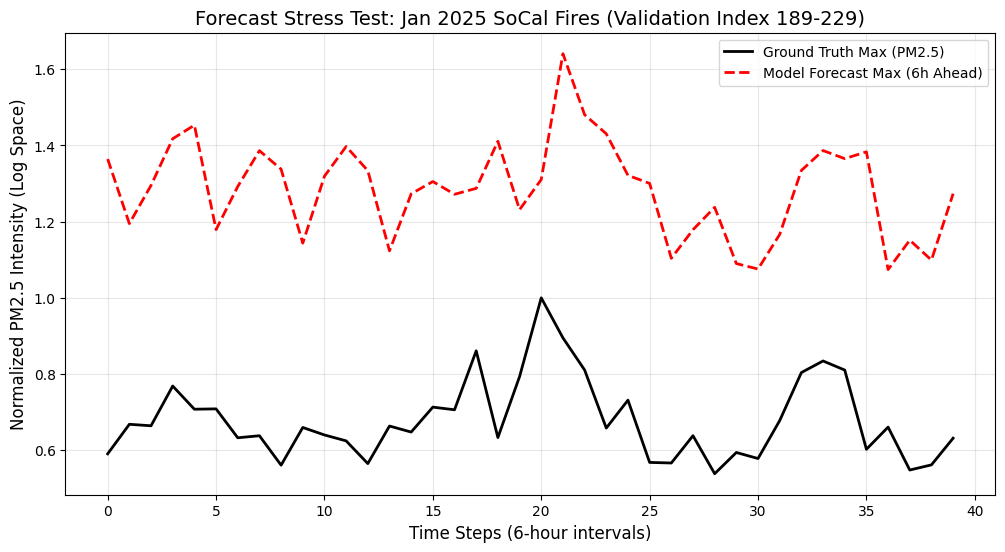

True Spike Amplitude: 0.4616
Predicted Spike Amplitude: 0.5666
Capture Ratio: 122.7%


In [ ]:
# ============================================================
# TEST-ONLY NOTEBOOK CELL (NO TRAINING)
# Loads: processed_simvp_data.npz + best_simvp_48h.pth
# Rebuilds: CONFIG, Dataset, Model, val_loader
# Runs: your existing plot_wildfire_event(...) unchanged
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import os, shutil
from google.colab import drive

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

# --------------------------
# Paths (same as training)
# --------------------------
NPZ_PATH  = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'
CKPT_PATH = '/content/drive/MyDrive/graphcast_project/best_simvp_48h_v1.pth'

NPZ_DRIVE  = '/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz'
CKPT_DRIVE = '/content/drive/MyDrive/graphcast_project/best_simvp_48h_v1.pth'

NPZ_LOCAL  = '/content/processed_simvp_data.npz'
CKPT_LOCAL = '/content/best_simvp_48h_v6.pth'

print("Copying files from Drive -> local disk...")
shutil.copy2(NPZ_DRIVE, NPZ_LOCAL)
shutil.copy2(CKPT_DRIVE, CKPT_LOCAL)

print("Local NPZ exists:", os.path.exists(NPZ_LOCAL), "size:", os.path.getsize(NPZ_LOCAL))
print("Local CKPT exists:", os.path.exists(CKPT_LOCAL), "size:", os.path.getsize(CKPT_LOCAL))

# Then use these local paths in the rest of your test code:
NPZ_PATH = NPZ_LOCAL
CKPT_PATH = CKPT_LOCAL

assert os.path.exists(NPZ_PATH),  f"❌ Missing NPZ: {NPZ_PATH}"
assert os.path.exists(CKPT_PATH), f"❌ Missing checkpoint: {CKPT_PATH}"

# ==========================
# 1. CONFIGURATION (same)
# ==========================
CONFIG = {
    'History': 8,        # 48 hours
    'Horizon': 1,        # 6 hours ahead
    'Batch_Size': 16,
    'Hid_S': 128,
    'Hid_T': 256,
    'Learning_Rate': 1e-3,
    'Epochs': 40,
    'Device': 'cuda' if torch.cuda.is_available() else 'cpu'
}
print("Device:", CONFIG["Device"])

# ==========================
# 2. DATASET (same)
# ==========================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Input
        x_seq = self.X[i : i + CONFIG['History']]
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        # Target
        target_idx = i + CONFIG['History'] + CONFIG['Horizon'] - 1
        y_target = self.Y[target_idx]
        mask = self.M[target_idx]

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())

# ==========================
# 3. RESIDUAL SIMVP (same)
# ==========================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()

        if out_c % 8 == 0: g = 8
        elif out_c % 4 == 0: g = 4
        else: g = 2
        self.norm = nn.GroupNorm(g, out_c)

        if transpose:
            self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2)
        else:
            self.conv = nn.Conv2d(in_c, out_c, k, s, p)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class ResidualSimVP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        hid_S, hid_T = CONFIG['Hid_S'], CONFIG['Hid_T']

        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )

    def forward(self, x):
        embed = self.enc(x)
        mid = self.mid(embed)
        delta = self.dec(mid)
        last_known_pollution = x[:, -6:, :, :]
        return last_known_pollution + delta

# ==========================
# 4. LOAD DATA + BUILD val_loader (same split logic)
# ==========================
print(">>> Loading processed data...")
data = np.load(NPZ_PATH)
X_full, Y_full, M_full = data['X'], data['Y'], data['Mask']

num_vars = X_full.shape[1]
in_dim = num_vars * CONFIG['History']
out_dim = 6

total_len = len(X_full) - CONFIG['History'] - CONFIG['Horizon'] + 1
train_idx_end = int(total_len * 0.85)

val_indices = range(train_idx_end, total_len)
val_ds   = PollutionDataset(X_full, Y_full, M_full, val_indices)
val_loader = DataLoader(val_ds, batch_size=CONFIG['Batch_Size'], shuffle=False, pin_memory=True)

print("X_full:", X_full.shape, "Y_full:", Y_full.shape, "Mask:", M_full.shape)
print("Val samples:", len(val_ds))

# ==========================
# 5. LOAD MODEL CHECKPOINT (no training)  ✅ robust to Hid_S changes
# ==========================
print(">>> Loading model checkpoint...")

# Load state FIRST (so we can infer the architecture)
state = torch.load(CKPT_PATH, map_location=CONFIG['Device'])

# Infer Hid_S from the checkpoint: enc.0.conv.weight shape = [Hid_S, in_dim, 3, 3]
# This works for your ResidualSimVP because it's always enc.0 in the Sequential encoder.
hid_s_ckpt = state["enc.0.conv.weight"].shape[0]
CONFIG["Hid_S"] = int(hid_s_ckpt)

# Infer Hid_T from checkpoint: mid.0.conv1.conv.weight shape = [Hid_T, Hid_S, 3, 3]
# (In your Inception blocks, conv1/2/3 output hid_T)
hid_t_ckpt = state["mid.0.conv1.conv.weight"].shape[0]
CONFIG["Hid_T"] = int(hid_t_ckpt)

print(f"✅ Detected checkpoint Hid_S={CONFIG['Hid_S']}  Hid_T={CONFIG['Hid_T']}")

# Now instantiate model with matching CONFIG
model = ResidualSimVP(in_channels=in_dim, out_channels=out_dim).to(CONFIG['Device'])
model.load_state_dict(state, strict=True)
model.eval()

print("✅ Loaded:", CKPT_PATH)

# ============================================================
# 6. YOUR TESTING CODE (logic unchanged)
# ============================================================
def plot_wildfire_event(model, val_loader, device='cuda'):
    """
    Plots the Jan 2025 Palisades/Eaton Fire event.
    """
    model.eval()

    print("Scanning validation set for maximum PM2.5 spike (The Fire)...")

    all_preds_max = []
    all_targets_max = []

    # Run inference on the whole validation set
    with torch.no_grad():
        for x, y, mask in val_loader:
            x = x.to(device)
            pred = model(x)

            # Channel 4 is PM2.5 in your list: ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
            # We take the MAX value over the grid (Spatial Max) to catch the fire hotspot
            all_preds_max.append(pred[:, 4, :, :].amax(dim=(1,2)).cpu().numpy())
            all_targets_max.append(y[:, 4, :, :].amax(dim=(1,2)).numpy())

    # Flatten into a single time series
    y_true = np.concatenate(all_targets_max)
    y_pred = np.concatenate(all_preds_max)

    # 2. LOCATE THE FIRE (The highest peak in the test set)
    peak_idx = np.argmax(y_true)
    print(f"Found Peak PM2.5 at Validation Index: {peak_idx}")

    # Zoom in: 10 days before and 10 days after the peak
    start_slice = max(0, peak_idx - 20)
    end_slice = min(len(y_true), peak_idx + 20)

    slice_true = y_true[start_slice:end_slice]
    slice_pred = y_pred[start_slice:end_slice]

    # 3. PLOT
    plt.figure(figsize=(12, 6))
    plt.plot(slice_true, label='Ground Truth Max (PM2.5)', color='black', linewidth=2)
    plt.plot(slice_pred, label='Model Forecast Max (6h Ahead)', color='red', linestyle='--', linewidth=2)

    plt.title(f"Forecast Stress Test: Jan 2025 SoCal Fires (Validation Index {start_slice}-{end_slice})", fontsize=14)
    plt.ylabel("Normalized PM2.5 Intensity (Log Space)", fontsize=12)
    plt.xlabel("Time Steps (6-hour intervals)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4. QUANTIFY THE 'JUMP' CAPTURE
    true_jump = slice_true.max() - slice_true.min()
    pred_jump = slice_pred.max() - slice_pred.min()
    print(f"True Spike Amplitude: {true_jump:.4f}")
    print(f"Predicted Spike Amplitude: {pred_jump:.4f}")
    print(f"Capture Ratio: {pred_jump/true_jump*100:.1f}%")

# Run test
plot_wildfire_event(model, val_loader, device=CONFIG['Device'])


GPT version

In [ ]:
# =========================
# 1) TRAINING CODE (fixed Horizon + safer decoder + safer GroupNorm)
#    - Fixes: Horizon indexing, total_len, decoder upsample, adaptive GroupNorm
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

CONFIG = {
    "History": 8,          # 48h
    "Horizon": 1,          # 6h ahead
    "Batch_Size": 16,
    "Hid_S": 128,
    "Hid_T": 256,
    "Learning_Rate": 1e-3,
    "Epochs": 40,
    "Device": 'cuda' if torch.cuda.is_available() else 'cpu',

    # If you know the order, set it here (default guess):
    "Target_Names": ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
}


print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_PATH = "/content/drive/MyDrive/graphcast_project/best_simvp_48h_GPT.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE =", DEVICE)


def adaptive_groupnorm(num_channels: int) -> nn.GroupNorm:
    # pick the largest groups that divides num_channels among [32,16,8,4,2,1]
    for g in [32, 16, 8, 4, 2, 1]:
        if num_channels % g == 0:
            return nn.GroupNorm(g, num_channels)
    return nn.GroupNorm(1, num_channels)


class PollutionDataset(Dataset):
    """
    X_full: (T, Cx, H, W)
    Y_full: (T, Cy, H, W)
    M_full: (T, 1 or Cy, H, W) mask for targets (1=valid)
    """
    def __init__(self, X_full, Y_full, M_full, indices, history, horizon):
        self.X = X_full
        self.Y = Y_full
        self.M = M_full
        self.indices = list(indices)
        self.history = history
        self.horizon = horizon

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        # Input times: [i, ..., i+history-1]
        x_seq = self.X[i : i + self.history]                 # (history, Cx, H, W)
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])  # (history*Cx, H, W)

        origin_t = i + self.history - 1
        target_t = origin_t + self.horizon                   # == i+history for horizon=1

        y_target = self.Y[target_t]                          # (Cy, H, W)
        mask = self.M[target_t]                              # (Cy or 1, H, W)

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())


class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, p=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=k, stride=s, padding=p)
        self.norm = adaptive_groupnorm(out_c)
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))


class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C * 3, C, 1, 1, 0, act=False)

    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))


class SimVP(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S, hid_T):
        super().__init__()

        # Encoder downsamples by 4x (stride 2 twice)
        self.enc1 = BasicConv2d(in_channels, hid_S, 3, 1, 1)
        self.enc2 = BasicConv2d(hid_S, hid_S, 3, 2, 1)
        self.enc3 = BasicConv2d(hid_S, hid_S, 3, 2, 1)

        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])

        # Decoder: Upsample + Conv (more stable than ConvTranspose2d for many grids)
        self.up1 = nn.Upsample(scale_factor=2, mode="nearest")
        self.dec1 = BasicConv2d(hid_S, hid_S, 3, 1, 1)

        self.up2 = nn.Upsample(scale_factor=2, mode="nearest")
        self.dec2 = BasicConv2d(hid_S, hid_S, 3, 1, 1)

        self.out = nn.Conv2d(hid_S, out_channels, 3, 1, 1)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.mid(x)
        x = self.up1(x); x = self.dec1(x)
        x = self.up2(x); x = self.dec2(x)
        return self.out(x)


class MaskedMAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.L1Loss(reduction="none")

    def forward(self, pred, target, mask):
        # allow mask shape (1,H,W) or (C,H,W)
        if mask.dim() == 3 and pred.shape[1] != mask.shape[0]:
            mask = mask.expand(pred.shape[1], -1, -1)
        elif mask.dim() == 4 and pred.shape[1] != mask.shape[1]:
            mask = mask.expand(-1, pred.shape[1], -1, -1)

        raw = self.loss_fn(pred, target)
        masked = raw * mask
        return masked.sum() / (mask.sum() + 1e-8)


def train_simvp():
    assert os.path.exists(DATA_PATH), f"Missing {DATA_PATH}"

    print("Loading NPZ:", DATA_PATH)
    data = np.load(DATA_PATH)
    X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]

    num_vars = X_full.shape[1]
    in_dim = num_vars * CONFIG["History"]
    out_dim = Y_full.shape[1]
    print(f"X_full: {X_full.shape}  Y_full: {Y_full.shape}  M_full: {M_full.shape}")
    print(f"Detected vars/time-step: {num_vars}  -> in_channels={in_dim}, out_channels={out_dim}")

    # number of samples possible
    total_len = len(X_full) - CONFIG["History"] - CONFIG["Horizon"] + 1
    assert total_len > 0, "Not enough data length for given History/Horizon"

    train_idx_end = int(total_len * 0.85)
    train_indices = range(0, train_idx_end)
    val_indices = range(train_idx_end, total_len)

    train_ds = PollutionDataset(X_full, Y_full, M_full, train_indices, CONFIG["History"], CONFIG["Horizon"])
    val_ds   = PollutionDataset(X_full, Y_full, M_full, val_indices, CONFIG["History"], CONFIG["Horizon"])

    train_loader = DataLoader(train_ds, batch_size=CONFIG["Batch_Size"], shuffle=True,  pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)

    model = SimVP(in_channels=in_dim, out_channels=out_dim, hid_S=CONFIG["Hid_S"], hid_T=CONFIG["Hid_T"]).to(CONFIG["Device"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["Learning_Rate"])
    criterion = MaskedMAE()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    best_val = float("inf")

    print("\n>>> START TRAIN")
    for epoch in range(CONFIG["Epochs"]):
        model.train()
        tr_sum = 0.0
        for x, y, m in train_loader:
            x, y, m = x.to(CONFIG["Device"]), y.to(CONFIG["Device"]), m.to(CONFIG["Device"])
            optimizer.zero_grad(set_to_none=True)
            pred = model(x)
            loss = criterion(pred, y, m)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            tr_sum += loss.item()

        avg_tr = tr_sum / max(1, len(train_loader))

        model.eval()
        va_sum = 0.0
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(CONFIG["Device"]), y.to(CONFIG["Device"]), m.to(CONFIG["Device"])
                pred = model(x)
                loss = criterion(pred, y, m)
                va_sum += loss.item()

        avg_va = va_sum / max(1, len(val_loader))
        scheduler.step(avg_va)
        lr = optimizer.param_groups[0]["lr"]

        saved = ""
        if avg_va < best_val:
            best_val = avg_va
            torch.save(model.state_dict(), CKPT_PATH)
            saved = "💾 Saved Best"

        print(f"Epoch {epoch+1:02d} | Train MAE: {avg_tr:.5f} | Val MAE: {avg_va:.5f} | LR: {lr:.1e} {saved}")

    print("✅ Training done. Best checkpoint:", CKPT_PATH)

# If you want to retrain using the fixed code:
train_simvp()


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEVICE = cuda
Loading NPZ: /content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz
X_full: (5108, 32, 88, 120)  Y_full: (5108, 6, 88, 120)  M_full: (5108, 6, 88, 120)
Detected vars/time-step: 32  -> in_channels=256, out_channels=6

>>> START TRAIN
Epoch 01 | Train MAE: 0.05166 | Val MAE: 0.03933 | LR: 1.0e-03 💾 Saved Best
Epoch 02 | Train MAE: 0.03721 | Val MAE: 0.03672 | LR: 1.0e-03 💾 Saved Best
Epoch 03 | Train MAE: 0.03377 | Val MAE: 0.03548 | LR: 1.0e-03 💾 Saved Best
Epoch 04 | Train MAE: 0.03161 | Val MAE: 0.03119 | LR: 1.0e-03 💾 Saved Best
Epoch 05 | Train MAE: 0.03000 | Val MAE: 0.03105 | LR: 1.0e-03 💾 Saved Best
Epoch 06 | Train MAE: 0.02901 | Val MAE: 0.03176 | LR: 1.0e-03 
Epoch 07 | Train MAE: 0.02798 | Val MAE: 0.03010 | LR: 1.0e-03 💾 Saved Best
Epoch 08 | Train MAE: 0.02727 | Val MAE: 0.03132 | LR:

Test against Y(t+6)=Y(t). we should be better than this

In [ ]:
# =========================
# 2) PERSISTENCE BASELINE: y(t+6) = y(t)
#    We compute baseline on validation using Y_full directly:
#      origin_t = i+History-1
#      target_t = origin_t + Horizon
#      baseline_pred = Y[origin_t]
# =========================
# --- Run this once at the top of the notebook ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

CONFIG = {
    "History": 8,          # 48h
    "Horizon": 1,          # 6h ahead
    "Batch_Size": 16,
    "Hid_S": 128,
    "Hid_T": 256,
    "Learning_Rate": 1e-3,
    "Epochs": 40,
    "Device": 'cuda' if torch.cuda.is_available() else 'cpu',

    # If you know the order, set it here (default guess):
    "Target_Names": ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]
}

print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE =", DEVICE)

DATA_PATH = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
#GPT version
#CKPT_PATH = "/content/drive/MyDrive/graphcast_project/best_simvp_48h_GPT.pth"
#GMINI version
CKPT_PATH = "/content/drive/MyDrive/graphcast_project/best_simvp_48h.pth"



def masked_metrics(pred, target, mask):
    """
    pred/target: torch tensors [B,C,H,W]
    mask: torch [B,1,H,W] or [B,C,H,W]
    returns dict with MAE, RMSE, R2 per-channel and overall (masked)
    """
    if mask.shape[1] == 1:
        maskC = mask.expand(-1, pred.shape[1], -1, -1)
    else:
        maskC = mask

    # flatten masked elements per channel
    # compute sums for MAE, MSE, and R2 components
    eps = 1e-8
    diff = (pred - target)
    abs_err = diff.abs() * maskC
    sq_err = (diff ** 2) * maskC

    # per channel
    msum = maskC.sum(dim=(0,2,3)) + eps
    mae_c = abs_err.sum(dim=(0,2,3)) / msum
    mse_c = sq_err.sum(dim=(0,2,3)) / msum
    rmse_c = torch.sqrt(mse_c)

    # R^2 per channel: 1 - SS_res/SS_tot
    # SS_res = sum((y - yhat)^2 * mask)
    # SS_tot = sum((y - ybar)^2 * mask), ybar computed over masked vals
    y = target
    y_sum = (y * maskC).sum(dim=(0,2,3))
    y_mean = y_sum / msum
    ss_tot = (((y - y_mean[None,:,None,None]) ** 2) * maskC).sum(dim=(0,2,3)) + eps
    ss_res = sq_err.sum(dim=(0,2,3))
    r2_c = 1.0 - (ss_res / ss_tot)

    # overall (weighted by mask count)
    mae = abs_err.sum() / (maskC.sum() + eps)
    rmse = torch.sqrt(sq_err.sum() / (maskC.sum() + eps))
    # overall R^2 (aggregate)
    y_sum_all = (y * maskC).sum()
    y_mean_all = y_sum_all / (maskC.sum() + eps)
    ss_tot_all = (((y - y_mean_all) ** 2) * maskC).sum() + eps
    ss_res_all = sq_err.sum()
    r2 = 1.0 - (ss_res_all / ss_tot_all)

    return {
        "MAE": mae.item(),
        "RMSE": rmse.item(),
        "R2": r2.item(),
        "MAE_c": mae_c.detach().cpu().numpy(),
        "RMSE_c": rmse_c.detach().cpu().numpy(),
        "R2_c": r2_c.detach().cpu().numpy(),
        "mask_count_c": msum.detach().cpu().numpy(),
    }


def eval_persistence_baseline_on_val():
    data = np.load(DATA_PATH)
    X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]
    Cy = Y_full.shape[1]

    total_len = len(X_full) - CONFIG["History"] - CONFIG["Horizon"] + 1
    train_idx_end = int(total_len * 0.85)
    val_indices = list(range(train_idx_end, total_len))

    # accumulate in torch for metrics
    mae_num = torch.zeros(Cy)
    mse_num = torch.zeros(Cy)
    msum = torch.zeros(Cy)
    y_sum = torch.zeros(Cy)
    y2_sum = torch.zeros(Cy)  # for SS_tot later

    # To compute R2, we do a 2-pass aggregate safely:
    # pass 1: compute y_mean per channel
    # pass 2: compute ss_tot and ss_res
    # We'll do it vectorized over all val samples in manageable batches.

    B = 256  # large CPU batch for numpy slicing
    # PASS 1: y_mean
    for start in range(0, len(val_indices), B):
        batch = val_indices[start:start+B]
        origin_t = np.array(batch) + CONFIG["History"] - 1
        target_t = origin_t + CONFIG["Horizon"]

        y = torch.from_numpy(Y_full[target_t]).float()   # [b,C,H,W]
        m = torch.from_numpy(M_full[target_t]).float()   # [b,1 or C,H,W]
        if m.dim() == 3: m = m.unsqueeze(1)
        if m.shape[1] == 1:
            m = m.expand(-1, Cy, -1, -1)

        msum += m.sum(dim=(0,2,3))
        y_sum += (y * m).sum(dim=(0,2,3))

    y_mean = y_sum / (msum + 1e-8)

    # PASS 2: ss_tot, ss_res, plus MAE/RMSE
    ss_tot = torch.zeros(Cy)
    ss_res = torch.zeros(Cy)

    for start in range(0, len(val_indices), B):
        batch = val_indices[start:start+B]
        origin_t = np.array(batch) + CONFIG["History"] - 1
        target_t = origin_t + CONFIG["Horizon"]

        y_true = torch.from_numpy(Y_full[target_t]).float()     # [b,C,H,W]
        m = torch.from_numpy(M_full[target_t]).float()
        if m.dim() == 3: m = m.unsqueeze(1)
        if m.shape[1] == 1:
            m = m.expand(-1, Cy, -1, -1)

        y_pred = torch.from_numpy(Y_full[origin_t]).float()     # persistence y(t)

        diff = (y_pred - y_true)
        abs_err = diff.abs() * m
        sq_err = (diff ** 2) * m

        mae_num += abs_err.sum(dim=(0,2,3))
        mse_num += sq_err.sum(dim=(0,2,3))

        # ss_tot uses y_mean
        ss_tot += (((y_true - y_mean[None,:,None,None]) ** 2) * m).sum(dim=(0,2,3))
        ss_res += sq_err.sum(dim=(0,2,3))

    mae_c = (mae_num / (msum + 1e-8)).numpy()
    rmse_c = torch.sqrt(mse_num / (msum + 1e-8)).numpy()
    r2_c = (1.0 - (ss_res / (ss_tot + 1e-8))).numpy()

    # overall
    mae = (mae_num.sum() / (msum.sum() + 1e-8)).item()
    rmse = torch.sqrt(mse_num.sum() / (msum.sum() + 1e-8)).item()
    r2 = (1.0 - (ss_res.sum() / (ss_tot.sum() + 1e-8))).item()

    print("\n=== Persistence baseline on VAL:  y(t+6)=y(t) ===")
    print(f"Overall   MAE:  {mae:.6f}   RMSE: {rmse:.6f}   R^2: {r2:.6f}")
    names = CONFIG["Target_Names"]
    for c in range(Cy):
        nm = names[c] if c < len(names) else f"Y{c}"
        print(f"{nm:>6s}  MAE: {mae_c[c]:.6f}  RMSE: {rmse_c[c]:.6f}  R^2: {r2_c[c]:.6f}")

# Run baseline:
eval_persistence_baseline_on_val()


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEVICE = cuda

=== Persistence baseline on VAL:  y(t+6)=y(t) ===
Overall   MAE:  0.031424   RMSE: 0.053295   R^2: 0.420934
    O3  MAE: 0.000903  RMSE: 0.001171  R^2: 0.346619
   SO2  MAE: 0.016606  RMSE: 0.029503  R^2: 0.486299
    CO  MAE: 0.007548  RMSE: 0.011649  R^2: 0.320882
   NO2  MAE: 0.058492  RMSE: 0.076878  R^2: 0.402765
  PM10  MAE: 0.054715  RMSE: 0.073937  R^2: 0.469965
 PM2.5  MAE: 0.046834  RMSE: 0.064704  R^2: 0.365856


Run statistics on validation data

In [ ]:
# ============================================================
# ONE-CELL FIX: matching SimVP architecture + time-based VAL split
# + loads checkpoint + computes MODEL vs PERSIST metrics (MAE/RMSE/R^2)
# + picks & plots 2 PM2.5 event days
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import drive
drive.mount("/content/drive")

# -----------------------
# CONFIG / PATHS
# -----------------------
CONFIG = {
    "History": 8,     # 48h (8*6h)
    "Horizon": 1,     # 6h ahead
    "Batch_Size": 16,
    "Hid_S": 128,
    "Hid_T": 256,
    "Device": "cuda" if torch.cuda.is_available() else "cpu",
    "Target_Names": ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"],  # your stated order
}
DATA_PATH = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_PATH = "/content/drive/MyDrive/graphcast_project/best_simvp_48h_v5.pth"

# Your stated time split (UTC, 6-hourly)
TRAIN_END = pd.Timestamp("2024-12-20 18:00:00", tz="UTC")
VAL_START = pd.Timestamp("2024-12-21 00:00:00", tz="UTC")
VAL_END   = pd.Timestamp("2025-06-30 18:00:00", tz="UTC")

# PM2.5 channel index based on Target_Names
PM25_CH = CONFIG["Target_Names"].index("PM2.5")


# ============================================================
# 1) Dataset with correct Horizon logic
# ============================================================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices, history, horizon):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = list(indices)
        self.history = history
        self.horizon = horizon

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        x_seq = self.X[i : i + self.history]  # (history, Cx, H, W)
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])

        origin_t = i + self.history - 1
        target_t = origin_t + self.horizon

        y_target = self.Y[target_t]          # (Cy, H, W)
        mask = self.M[target_t]              # (1 or Cy, H, W)

        return (
            torch.from_numpy(x_flat).float(),
            torch.from_numpy(y_target).float(),
            torch.from_numpy(mask).float(),
        )


# ============================================================
# 2) SimVP that MATCHES your saved checkpoint keys (enc.0 / dec.0)
# ============================================================
class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2) if transpose else nn.Conv2d(in_c, out_c, k, s, p)
        self.norm = nn.GroupNorm(2, out_c)
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))

class SimVP(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S=128, hid_T=256):
        super().__init__()
        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )
    def forward(self, x):
        return self.dec(self.mid(self.enc(x)))


# ============================================================
# 3) Build VAL loader using your DATE split (not 0.85)
# ============================================================
def build_val_loader():
    assert os.path.exists(DATA_PATH), f"Missing {DATA_PATH}"
    data = np.load(DATA_PATH)
    X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]

    T = X_full.shape[0]
    Cx = X_full.shape[1]
    Cy = Y_full.shape[1]

    # assumes NPZ starts at 2022-01-01 00Z, 6-hour cadence
    time_index = pd.date_range("2022-01-01 00:00:00", periods=T, freq="6H", tz="UTC")

    total_len = T - CONFIG["History"] - CONFIG["Horizon"] + 1
    i_all = np.arange(total_len)

    origin_t = i_all + CONFIG["History"] - 1
    target_t = origin_t + CONFIG["Horizon"]
    target_times = time_index[target_t]

    val_mask = (target_times >= VAL_START) & (target_times <= VAL_END)
    val_indices = i_all[val_mask].tolist()

    print("Total possible samples:", total_len)
    print("VAL samples:", len(val_indices))
    if len(val_indices) > 0:
        print("VAL target range:", target_times[val_mask].min(), "→", target_times[val_mask].max())

    in_dim = Cx * CONFIG["History"]
    out_dim = Cy

    val_ds = PollutionDataset(X_full, Y_full, M_full, val_indices, CONFIG["History"], CONFIG["Horizon"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)

    return X_full, Y_full, M_full, time_index, val_indices, in_dim, out_dim, val_loader


# ============================================================
# 4) Load checkpoint safely
# ============================================================
def load_model(in_dim, out_dim):
    assert os.path.exists(CKPT_PATH), f"Missing checkpoint: {CKPT_PATH}"
    model = SimVP(in_channels=in_dim, out_channels=out_dim, hid_S=CONFIG["Hid_S"], hid_T=CONFIG["Hid_T"]).to(CONFIG["Device"])
    state = torch.load(CKPT_PATH, map_location=CONFIG["Device"])
    # sanity: key style check
    k0 = next(iter(state.keys()))
    print("Checkpoint key sample:", k0)
    model.load_state_dict(state, strict=True)
    model.eval()
    print("✅ Loaded:", CKPT_PATH)
    return model


# ============================================================
# 5) Metrics (masked MAE/RMSE/R^2) for model and persistence
# ============================================================
def masked_metrics_from_sums(abs_sum, sq_sum, msum, ss_res, ss_tot):
    mae_c = (abs_sum / (msum + 1e-8)).cpu().numpy()
    rmse_c = torch.sqrt(sq_sum / (msum + 1e-8)).cpu().numpy()
    r2_c = (1.0 - (ss_res / (ss_tot + 1e-8))).cpu().numpy()

    mae = (abs_sum.sum() / (msum.sum() + 1e-8)).item()
    rmse = torch.sqrt(sq_sum.sum() / (msum.sum() + 1e-8)).item()
    r2 = (1.0 - (ss_res.sum() / (ss_tot.sum() + 1e-8))).item()
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAE_c": mae_c, "RMSE_c": rmse_c, "R2_c": r2_c}

@torch.no_grad()
def eval_model_on_val(model, val_loader):
    device = CONFIG["Device"]
    first = True

    # PASS 1: compute masked y_mean per channel
    msum = None
    ysum = None
    for x, y, m in val_loader:
        x, y, m = x.to(device), y.to(device), m.to(device)
        if m.ndim == 3:
            m = m[:, None, :, :]
        if m.shape[1] == 1:
            mC = m.expand(-1, y.shape[1], -1, -1)
        else:
            mC = m
        if first:
            C = y.shape[1]
            msum = torch.zeros(C, device=device)
            ysum = torch.zeros(C, device=device)
            first = False
        msum += mC.sum(dim=(0,2,3))
        ysum += (y * mC).sum(dim=(0,2,3))

    y_mean = ysum / (msum + 1e-8)

    # PASS 2: MAE/RMSE + SS_res/SS_tot
    abs_sum = torch.zeros_like(msum)
    sq_sum  = torch.zeros_like(msum)
    ss_res  = torch.zeros_like(msum)
    ss_tot  = torch.zeros_like(msum)

    for x, y, m in val_loader:
        x, y, m = x.to(device), y.to(device), m.to(device)
        if m.ndim == 3:
            m = m[:, None, :, :]
        if m.shape[1] == 1:
            mC = m.expand(-1, y.shape[1], -1, -1)
        else:
            mC = m

        pred = model(x)
        diff = pred - y

        abs_sum += (diff.abs() * mC).sum(dim=(0,2,3))
        sq_sum  += ((diff**2) * mC).sum(dim=(0,2,3))

        ss_res += (((pred - y)**2) * mC).sum(dim=(0,2,3))
        ss_tot += (((y - y_mean[None,:,None,None])**2) * mC).sum(dim=(0,2,3))

    return masked_metrics_from_sums(abs_sum, sq_sum, msum, ss_res, ss_tot)

def eval_persistence_on_val(Y_full, M_full, val_indices, time_index):
    Cy = Y_full.shape[1]
    history = CONFIG["History"]
    horizon = CONFIG["Horizon"]

    # PASS 1: y_mean (masked)
    msum = torch.zeros(Cy)
    ysum = torch.zeros(Cy)

    B = 256
    for s in range(0, len(val_indices), B):
        batch = np.array(val_indices[s:s+B])
        origin_t = batch + history - 1
        target_t = origin_t + horizon

        y = torch.from_numpy(Y_full[target_t]).float()
        m = torch.from_numpy(M_full[target_t]).float()
        if m.ndim == 3: m = m[:, None, :, :]
        if m.shape[1] == 1:
            m = m.expand(-1, Cy, -1, -1)

        msum += m.sum(dim=(0,2,3))
        ysum += (y * m).sum(dim=(0,2,3))

    y_mean = ysum / (msum + 1e-8)

    # PASS 2: MAE/RMSE + SS_res/SS_tot
    abs_sum = torch.zeros(Cy)
    sq_sum  = torch.zeros(Cy)
    ss_res  = torch.zeros(Cy)
    ss_tot  = torch.zeros(Cy)

    for s in range(0, len(val_indices), B):
        batch = np.array(val_indices[s:s+B])
        origin_t = batch + history - 1
        target_t = origin_t + horizon

        y_true = torch.from_numpy(Y_full[target_t]).float()
        y_pred = torch.from_numpy(Y_full[origin_t]).float()

        m = torch.from_numpy(M_full[target_t]).float()
        if m.ndim == 3: m = m[:, None, :, :]
        if m.shape[1] == 1:
            m = m.expand(-1, Cy, -1, -1)

        diff = y_pred - y_true

        abs_sum += (diff.abs() * m).sum(dim=(0,2,3))
        sq_sum  += ((diff**2) * m).sum(dim=(0,2,3))

        ss_res += (((y_pred - y_true)**2) * m).sum(dim=(0,2,3))
        ss_tot += (((y_true - y_mean[None,:,None,None])**2) * m).sum(dim=(0,2,3))

    return masked_metrics_from_sums(abs_sum, sq_sum, msum, ss_res, ss_tot)


# ============================================================
# 6) Pick & plot event days (VAL only)
# ============================================================
def pick_event_days(Y_full, val_indices, time_index, pm25_channel, top_k_days=2):

    val_i = np.array(val_indices)
    origin_t = val_i + CONFIG["History"] - 1
    target_t = origin_t + CONFIG["Horizon"]

    pm = Y_full[target_t, pm25_channel]  # [N,H,W]
    scores = np.nanmean(pm.reshape(pm.shape[0], -1), axis=1)

    dates = time_index[target_t].date
    df = pd.DataFrame({"date": dates, "score": scores})
    day_scores = df.groupby("date")["score"].mean().sort_values(ascending=False)

    chosen = list(day_scores.head(top_k_days).index)
    print("Chosen event days (UTC):", chosen)
    return chosen

@torch.no_grad()
@torch.no_grad()
def plot_event_days(model, X_full, Y_full, M_full, val_indices, event_days, time_index, pm25_channel):


    device = CONFIG["Device"]
    val_i = np.array(val_indices)
    origin_t = val_i + CONFIG["History"] - 1
    target_t = origin_t + CONFIG["Horizon"]

    def get_2d_mask(m_raw, c):
        """
        Convert mask at one time to a 2D (H,W) mask for channel c.
        Accepts shapes:
          (H,W)
          (1,H,W)
          (C,H,W)
          (1,C,H,W)  <-- sometimes appears due to earlier expansion mistakes
        """
        m = m_raw
        if m.ndim == 2:
            return m
        if m.ndim == 3:
            # either (1,H,W) or (C,H,W)
            if m.shape[0] == 1:
                return m[0]
            else:
                return m[c]
        if m.ndim == 4:
            # either (1,C,H,W) or (B,C,H,W) – take first batch
            if m.shape[0] == 1:
                m = m[0]
            else:
                m = m[0]
            # now m is (C,H,W) or (H,W)
            return get_2d_mask(m, c)
        raise ValueError(f"Unsupported mask shape: {m.shape}")

    for day in event_days:
        mask_day = (time_index[target_t].date == day)
        t1s = target_t[mask_day]
        t0s = origin_t[mask_day]
        isel = val_i[mask_day]

        if len(t1s) == 0:
            continue

        take = min(4, len(t1s))
        t1s, t0s, isel = t1s[:take], t0s[:take], isel[:take]

        fig, axes = plt.subplots(take, 4, figsize=(16, 4*take))
        if take == 1:
            axes = np.expand_dims(axes, axis=0)

        for r in range(take):
            i = int(isel[r])
            t0 = int(t0s[r])
            t1 = int(t1s[r])

            # input
            x_seq = X_full[i : i + CONFIG["History"]]
            x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])
            x = torch.from_numpy(x_flat).float().unsqueeze(0).to(device)

            pred = model(x).squeeze(0).detach().cpu().numpy()  # (C,H,W)
            true = Y_full[t1]                                   # (C,H,W)
            pers = Y_full[t0]                                   # (C,H,W)

            # mask (force to 2D)
            m_raw = M_full[t1]
            p_mask = get_2d_mask(m_raw, pm25_channel)  # (H,W)
            p_mask = (p_mask >= 0.5)

            def apply_mask(a2d):
                a2d = a2d.astype(np.float32, copy=True)
                a2d[~p_mask] = np.nan
                return a2d

            ts = str(time_index[t1])

            axes[r,0].imshow(apply_mask(true[pm25_channel]))
            axes[r,0].set_title(f"TRUE PM2.5\n{ts}")
            axes[r,0].axis("off")

            axes[r,1].imshow(apply_mask(pred[pm25_channel]))
            axes[r,1].set_title("MODEL PM2.5")
            axes[r,1].axis("off")

            axes[r,2].imshow(apply_mask(pers[pm25_channel]))
            axes[r,2].set_title("PERSIST PM2.5")
            axes[r,2].axis("off")

            err = np.abs(pred[pm25_channel] - true[pm25_channel])
            axes[r,3].imshow(apply_mask(err))
            axes[r,3].set_title("|ERR| PM2.5")
            axes[r,3].axis("off")

        plt.tight_layout()
        plt.show()


# ============================================================
# 7) RUN EVERYTHING
# ============================================================
def full_validation_report_and_plots(top_k_days=2):
    X_full, Y_full, M_full, time_index, val_indices, in_dim, out_dim, val_loader = build_val_loader()
    model = load_model(in_dim, out_dim)

    model_metrics = eval_model_on_val(model, val_loader)
    pers_metrics  = eval_persistence_on_val(Y_full, M_full, val_indices, time_index)

    print("\n==================== VAL METRICS (MASKED) ====================")
    print(f"MODEL    MAE: {model_metrics['MAE']:.6f} | RMSE: {model_metrics['RMSE']:.6f} | R^2: {model_metrics['R2']:.6f}")
    print(f"PERSIST  MAE: {pers_metrics['MAE']:.6f} | RMSE: {pers_metrics['RMSE']:.6f} | R^2: {pers_metrics['R2']:.6f}")

    names = CONFIG["Target_Names"]
    for c in range(out_dim):
        nm = names[c] if c < len(names) else f"Y{c}"
        print(f"{nm:>6s} | MODEL  MAE {model_metrics['MAE_c'][c]:.6f}  RMSE {model_metrics['RMSE_c'][c]:.6f}  R^2 {model_metrics['R2_c'][c]:.6f}"
              f" || PERSIST MAE {pers_metrics['MAE_c'][c]:.6f}  RMSE {pers_metrics['RMSE_c'][c]:.6f}  R^2 {pers_metrics['R2_c'][c]:.6f}")

    event_days = pick_event_days(Y_full, val_indices, time_index, pm25_channel=PM25_CH, top_k_days=top_k_days)
    plot_event_days(model, X_full, Y_full, M_full, val_indices, event_days, time_index, pm25_channel=PM25_CH)

# Execute:
full_validation_report_and_plots(top_k_days=2)





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-1004243530.py:130: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range("2022-01-01 00:00:00", periods=T, freq="6H", tz="UTC")


Total possible samples: 5100
VAL samples: 768
VAL target range: 2024-12-21 00:00:00+00:00 → 2025-06-30 18:00:00+00:00
Checkpoint key sample: enc.0.norm.weight


RuntimeError: Error(s) in loading state_dict for SimVP:
	size mismatch for enc.0.conv.weight: copying a param with shape torch.Size([64, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([128, 256, 3, 3]).
	size mismatch for enc.0.conv.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.0.norm.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.0.norm.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for enc.1.conv.weight: copying a param with shape torch.Size([64, 64, 3, 3]) from checkpoint, the shape in current model is torch.Size([128, 128, 3, 3]).
	size mismatch for enc.1.conv.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for 

In [ ]:
# ============================================================
# ONE-CELL EVAL (AUTO-MATCH CHECKPOINT): metrics + baseline + plots
# Works with BOTH checkpoint formats:
#   - Sequential keys: enc.0.*, dec.0.*
#   - Named-layer keys: enc1.*, dec1.*, out.*
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import drive
drive.mount("/content/drive")

# -----------------------
# CONFIG / PATHS
# -----------------------
CONFIG = {
    "History": 8,
    "Horizon": 1,
    "Batch_Size": 16,
    "Hid_S": 128,
    "Hid_T": 256,
    "Device": "cuda" if torch.cuda.is_available() else "cpu",
    "Target_Names": ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"],  # adjust if needed
}
DATA_PATH = "/content/drive/MyDrive/graphcast_project/Training Data/processed_simvp_data.npz"
CKPT_PATH = "/content/drive/MyDrive/graphcast_project/best_simvp_48h.pth"  # <-- your new model path

TRAIN_END = pd.Timestamp("2024-12-20 18:00:00", tz="UTC")
VAL_START = pd.Timestamp("2024-12-21 00:00:00", tz="UTC")
VAL_END   = pd.Timestamp("2025-06-30 18:00:00", tz="UTC")

PM25_CH = CONFIG["Target_Names"].index("PM2.5")


# ============================================================
# Dataset (correct horizon logic)
# ============================================================
class PollutionDataset(Dataset):
    def __init__(self, X_data, Y_data, Mask_data, indices, history, horizon):
        self.X = X_data
        self.Y = Y_data
        self.M = Mask_data
        self.indices = list(indices)
        self.history = history
        self.horizon = horizon

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        x_seq = self.X[i : i + self.history]              # (history, Cx, H, W)
        x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])  # (history*Cx, H, W)

        origin_t = i + self.history - 1
        target_t = origin_t + self.horizon

        y_target = self.Y[target_t]                       # (Cy, H, W)
        mask = self.M[target_t]                           # (1,H,W) or (Cy,H,W)

        return (torch.from_numpy(x_flat).float(),
                torch.from_numpy(y_target).float(),
                torch.from_numpy(mask).float())


# ============================================================
# Model building blocks
# ============================================================
def adaptive_groupnorm(out_c):
    # your original was GroupNorm(2, out_c). Keep it to match training.
    return nn.GroupNorm(2, out_c)

class BasicConv2d(nn.Module):
    def __init__(self, in_c, out_c, k, s, p, transpose=False, act=True):
        super().__init__()
        self.conv = nn.ConvTranspose2d(in_c, out_c, k, s, p, output_padding=s//2) if transpose else nn.Conv2d(in_c, out_c, k, s, p)
        self.norm = adaptive_groupnorm(out_c)
        self.act = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, C, hid_C):
        super().__init__()
        self.conv1 = BasicConv2d(C, hid_C, 3, 1, 1)
        self.conv2 = BasicConv2d(C, hid_C, 5, 1, 2)
        self.conv3 = BasicConv2d(C, hid_C, 7, 1, 3)
        self.cat_conv = BasicConv2d(hid_C*3, C, 1, 1, 0, act=False)
    def forward(self, x):
        return self.cat_conv(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1))


# ============================================================
# SimVP Variant A: Sequential keys (enc.0.*, dec.0.*)
# ============================================================
class SimVP_Sequential(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S=128, hid_T=256):
        super().__init__()
        self.enc = nn.Sequential(
            BasicConv2d(in_channels, hid_S, 3, 1, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1),
            BasicConv2d(hid_S, hid_S, 3, 2, 1)
        )
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec = nn.Sequential(
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True),
            nn.Conv2d(hid_S, out_channels, 3, 1, 1)
        )
    def forward(self, x):
        return self.dec(self.mid(self.enc(x)))


# ============================================================
# SimVP Variant B: Named-layer keys (enc1.*, dec1.*, out.*)
# ============================================================
class SimVP_Named(nn.Module):
    def __init__(self, in_channels, out_channels, hid_S=128, hid_T=256):
        super().__init__()
        self.enc1 = BasicConv2d(in_channels, hid_S, 3, 1, 1)
        self.enc2 = BasicConv2d(hid_S, hid_S, 3, 2, 1)
        self.enc3 = BasicConv2d(hid_S, hid_S, 3, 2, 1)
        self.mid = nn.Sequential(*[Inception(hid_S, hid_T) for _ in range(4)])
        self.dec1 = BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True)
        self.dec2 = BasicConv2d(hid_S, hid_S, 3, 2, 1, transpose=True)
        self.out  = nn.Conv2d(hid_S, out_channels, 3, 1, 1)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.mid(x)
        x = self.dec1(x)
        x = self.dec2(x)
        return self.out(x)


# ============================================================
# Build VAL loader using date split
# ============================================================
def build_val_loader():
    assert os.path.exists(DATA_PATH), f"Missing {DATA_PATH}"
    data = np.load(DATA_PATH)
    X_full, Y_full, M_full = data["X"], data["Y"], data["Mask"]

    T = X_full.shape[0]
    Cx = X_full.shape[1]
    Cy = Y_full.shape[1]

    # use '6h' to avoid FutureWarning
    time_index = pd.date_range("2022-01-01 00:00:00", periods=T, freq="6h", tz="UTC")

    total_len = T - CONFIG["History"] - CONFIG["Horizon"] + 1
    i_all = np.arange(total_len)

    origin_t = i_all + CONFIG["History"] - 1
    target_t = origin_t + CONFIG["Horizon"]
    target_times = time_index[target_t]

    val_mask = (target_times >= VAL_START) & (target_times <= VAL_END)
    val_indices = i_all[val_mask].tolist()

    print("Total possible samples:", total_len)
    print("VAL samples:", len(val_indices))
    if len(val_indices):
        print("VAL target range:", target_times[val_mask].min(), "→", target_times[val_mask].max())

    in_dim = Cx * CONFIG["History"]
    out_dim = Cy

    val_ds = PollutionDataset(X_full, Y_full, M_full, val_indices, CONFIG["History"], CONFIG["Horizon"])
    val_loader = DataLoader(val_ds, batch_size=CONFIG["Batch_Size"], shuffle=False, pin_memory=True)

    return X_full, Y_full, M_full, time_index, val_indices, in_dim, out_dim, val_loader


# ============================================================
# Auto-load correct model variant based on checkpoint keys
# ============================================================
def load_model_auto(in_dim, out_dim):
    assert os.path.exists(CKPT_PATH), f"Missing checkpoint: {CKPT_PATH}"
    state = torch.load(CKPT_PATH, map_location=CONFIG["Device"])
    k0 = next(iter(state.keys()))
    print("Checkpoint key sample:", k0)

    if k0.startswith("enc.0") or any(k.startswith("enc.0") for k in state.keys()):
        model = SimVP_Sequential(in_channels=in_dim, out_channels=out_dim, hid_S=CONFIG["Hid_S"], hid_T=CONFIG["Hid_T"]).to(CONFIG["Device"])
    elif k0.startswith("enc1") or any(k.startswith("enc1") for k in state.keys()):
        model = SimVP_Named(in_channels=in_dim, out_channels=out_dim, hid_S=CONFIG["Hid_S"], hid_T=CONFIG["Hid_T"]).to(CONFIG["Device"])
    else:
        raise RuntimeError("Unknown checkpoint key format. First keys: " + str(list(state.keys())[:10]))

    model.load_state_dict(state, strict=True)
    model.eval()
    print("✅ Loaded:", CKPT_PATH)
    return model


# ============================================================
# Mask utilities + metrics
# ============================================================
def ensure_mask_bc_hw(mask, C):
    # mask: torch [B,1,H,W] or [B,C,H,W] or [B,H,W]
    if mask.dim() == 3:
        mask = mask.unsqueeze(1)
    if mask.shape[1] == 1:
        mask = mask.expand(-1, C, -1, -1)
    return mask

def metrics_two_pass(pred_fn, val_loader, y_mean=None):
    """
    Two-pass masked metrics to get R^2 correctly.
    pred_fn(x,y,m) returns pred tensor [B,C,H,W]
    """
    device = CONFIG["Device"]
    first = True

    # PASS 1: compute y_mean
    msum = None
    ysum = None
    for x, y, m in val_loader:
        x, y, m = x.to(device), y.to(device), m.to(device)
        mC = ensure_mask_bc_hw(m, y.shape[1])
        if first:
            C = y.shape[1]
            msum = torch.zeros(C, device=device)
            ysum = torch.zeros(C, device=device)
            first = False
        msum += mC.sum(dim=(0,2,3))
        ysum += (y * mC).sum(dim=(0,2,3))
    y_mean = ysum / (msum + 1e-8)

    # PASS 2: MAE/RMSE + R^2
    abs_sum = torch.zeros_like(msum)
    sq_sum  = torch.zeros_like(msum)
    ss_res  = torch.zeros_like(msum)
    ss_tot  = torch.zeros_like(msum)

    for x, y, m in val_loader:
        x, y, m = x.to(device), y.to(device), m.to(device)
        mC = ensure_mask_bc_hw(m, y.shape[1])
        pred = pred_fn(x, y, mC)
        diff = pred - y

        abs_sum += (diff.abs() * mC).sum(dim=(0,2,3))
        sq_sum  += ((diff**2) * mC).sum(dim=(0,2,3))
        ss_res  += (((pred - y)**2) * mC).sum(dim=(0,2,3))
        ss_tot  += (((y - y_mean[None,:,None,None])**2) * mC).sum(dim=(0,2,3))

    mae_c = (abs_sum / (msum + 1e-8)).detach().cpu().numpy()
    rmse_c = torch.sqrt(sq_sum / (msum + 1e-8)).detach().cpu().numpy()
    r2_c = (1.0 - (ss_res / (ss_tot + 1e-8))).detach().cpu().numpy()

    mae = (abs_sum.sum() / (msum.sum() + 1e-8)).item()
    rmse = torch.sqrt(sq_sum.sum() / (msum.sum() + 1e-8)).item()
    r2 = (1.0 - (ss_res.sum() / (ss_tot.sum() + 1e-8))).item()
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAE_c": mae_c, "RMSE_c": rmse_c, "R2_c": r2_c}


# ============================================================
# Persistence baseline using arrays (y(t+6)=y(t))
# ============================================================
def build_val_origin_target_indices(val_indices):
    val_i = np.array(val_indices)
    origin_t = val_i + CONFIG["History"] - 1
    target_t = origin_t + CONFIG["Horizon"]
    return origin_t, target_t

def eval_persistence_arrays(Y_full, M_full, val_indices):
    origin_t, target_t = build_val_origin_target_indices(val_indices)

    # Build a loader-like iterator of batches over indices for convenience
    B = 256
    Cy = Y_full.shape[1]

    # PASS 1: y_mean
    msum = torch.zeros(Cy)
    ysum = torch.zeros(Cy)

    for s in range(0, len(val_indices), B):
        t1 = target_t[s:s+B]
        y = torch.from_numpy(Y_full[t1]).float()
        m = torch.from_numpy(M_full[t1]).float()
        if m.ndim == 3: m = m[:, None, :, :]
        if m.shape[1] == 1: m = m.expand(-1, Cy, -1, -1)

        msum += m.sum(dim=(0,2,3))
        ysum += (y * m).sum(dim=(0,2,3))
    y_mean = ysum / (msum + 1e-8)

    # PASS 2
    abs_sum = torch.zeros(Cy)
    sq_sum  = torch.zeros(Cy)
    ss_res  = torch.zeros(Cy)
    ss_tot  = torch.zeros(Cy)

    for s in range(0, len(val_indices), B):
        t0 = origin_t[s:s+B]
        t1 = target_t[s:s+B]

        y_true = torch.from_numpy(Y_full[t1]).float()
        y_pred = torch.from_numpy(Y_full[t0]).float()
        m = torch.from_numpy(M_full[t1]).float()
        if m.ndim == 3: m = m[:, None, :, :]
        if m.shape[1] == 1: m = m.expand(-1, Cy, -1, -1)

        diff = y_pred - y_true
        abs_sum += (diff.abs() * m).sum(dim=(0,2,3))
        sq_sum  += ((diff**2) * m).sum(dim=(0,2,3))
        ss_res  += (((y_pred - y_true)**2) * m).sum(dim=(0,2,3))
        ss_tot  += (((y_true - y_mean[None,:,None,None])**2) * m).sum(dim=(0,2,3))

    mae_c = (abs_sum / (msum + 1e-8)).numpy()
    rmse_c = torch.sqrt(sq_sum / (msum + 1e-8)).numpy()
    r2_c = (1.0 - (ss_res / (ss_tot + 1e-8))).numpy()

    mae = (abs_sum.sum() / (msum.sum() + 1e-8)).item()
    rmse = torch.sqrt(sq_sum.sum() / (msum.sum() + 1e-8)).item()
    r2 = (1.0 - (ss_res.sum() / (ss_tot.sum() + 1e-8))).item()
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAE_c": mae_c, "RMSE_c": rmse_c, "R2_c": r2_c}


# ============================================================
# Event-day picker + plotting (robust mask shape handling)
# ============================================================
def get_2d_mask(m_raw, c):
    # supports (H,W), (1,H,W), (C,H,W), (1,C,H,W)
    m = m_raw
    if m.ndim == 2:
        return m
    if m.ndim == 3:
        return m[0] if m.shape[0] == 1 else m[c]
    if m.ndim == 4:
        m = m[0]
        return get_2d_mask(m, c)
    raise ValueError(f"Unsupported mask shape: {m.shape}")

def pick_event_days(Y_full, val_indices, time_index, pm25_channel, top_k_days=2):
    origin_t, target_t = build_val_origin_target_indices(val_indices)
    pm = Y_full[target_t, pm25_channel]  # [N,H,W]
    scores = np.nanmean(pm.reshape(pm.shape[0], -1), axis=1)
    dates = time_index[target_t].date
    df = pd.DataFrame({"date": dates, "score": scores})
    chosen = list(df.groupby("date")["score"].mean().sort_values(ascending=False).head(top_k_days).index)
    print("Chosen event days (UTC):", chosen)
    return chosen

@torch.no_grad()
def plot_event_days(model, X_full, Y_full, M_full, val_indices, event_days, time_index, pm25_channel):
    device = CONFIG["Device"]
    origin_t, target_t = build_val_origin_target_indices(val_indices)
    val_i = np.array(val_indices)

    for day in event_days:
        mask_day = (time_index[target_t].date == day)
        t1s = target_t[mask_day]
        t0s = origin_t[mask_day]
        isel = val_i[mask_day]
        if len(t1s) == 0:
            continue

        take = min(4, len(t1s))
        t1s, t0s, isel = t1s[:take], t0s[:take], isel[:take]

        fig, axes = plt.subplots(take, 4, figsize=(16, 4*take))
        if take == 1:
            axes = np.expand_dims(axes, axis=0)

        for r in range(take):
            i = int(isel[r]); t0 = int(t0s[r]); t1 = int(t1s[r])

            x_seq = X_full[i : i + CONFIG["History"]]
            x_flat = x_seq.reshape(-1, x_seq.shape[2], x_seq.shape[3])
            x = torch.from_numpy(x_flat).float().unsqueeze(0).to(device)

            pred = model(x).squeeze(0).detach().cpu().numpy()  # (C,H,W)
            true = Y_full[t1]
            pers = Y_full[t0]

            p_mask = get_2d_mask(M_full[t1], pm25_channel)  # (H,W)
            p_mask = (p_mask >= 0.5)

            def apply_mask(a2d):
                a2d = a2d.astype(np.float32, copy=True)
                a2d[~p_mask] = np.nan
                return a2d

            ts = str(time_index[t1])

            axes[r,0].imshow(apply_mask(true[pm25_channel])); axes[r,0].set_title(f"TRUE PM2.5\n{ts}"); axes[r,0].axis("off")
            axes[r,1].imshow(apply_mask(pred[pm25_channel])); axes[r,1].set_title("MODEL PM2.5"); axes[r,1].axis("off")
            axes[r,2].imshow(apply_mask(pers[pm25_channel])); axes[r,2].set_title("PERSIST PM2.5"); axes[r,2].axis("off")
            axes[r,3].imshow(apply_mask(np.abs(pred[pm25_channel] - true[pm25_channel]))); axes[r,3].set_title("|ERR| PM2.5"); axes[r,3].axis("off")

        plt.tight_layout()
        plt.show()


# ============================================================
# RUN EVERYTHING
# ============================================================
def full_validation_report_and_plots(top_k_days=2):
    X_full, Y_full, M_full, time_index, val_indices, in_dim, out_dim, val_loader = build_val_loader()
    model = load_model_auto(in_dim, out_dim)

    # Model metrics
    model_metrics = metrics_two_pass(lambda x, y, m: model(x), val_loader)

    # Persistence metrics
    pers_metrics = eval_persistence_arrays(Y_full, M_full, val_indices)

    print("\n==================== VAL METRICS (MASKED) ====================")
    print(f"MODEL    MAE: {model_metrics['MAE']:.6f} | RMSE: {model_metrics['RMSE']:.6f} | R^2: {model_metrics['R2']:.6f}")
    print(f"PERSIST  MAE: {pers_metrics['MAE']:.6f} | RMSE: {pers_metrics['RMSE']:.6f} | R^2: {pers_metrics['R2']:.6f}")

    names = CONFIG["Target_Names"]
    for c in range(out_dim):
        nm = names[c] if c < len(names) else f"Y{c}"
        print(f"{nm:>6s} | MODEL  MAE {model_metrics['MAE_c'][c]:.6f}  RMSE {model_metrics['RMSE_c'][c]:.6f}  R^2 {model_metrics['R2_c'][c]:.6f}"
              f" || PERSIST MAE {pers_metrics['MAE_c'][c]:.6f}  RMSE {pers_metrics['RMSE_c'][c]:.6f}  R^2 {pers_metrics['R2_c'][c]:.6f}")

    event_days = pick_event_days(Y_full, val_indices, time_index, pm25_channel=PM25_CH, top_k_days=top_k_days)
    plot_event_days(model, X_full, Y_full, M_full, val_indices, event_days, time_index, pm25_channel=PM25_CH)

full_validation_report_and_plots(top_k_days=2)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total possible samples: 5100
VAL samples: 768
VAL target range: 2024-12-21 00:00:00+00:00 → 2025-06-30 18:00:00+00:00
Checkpoint key sample: enc.0.conv.weight
✅ Loaded: /content/drive/MyDrive/graphcast_project/best_simvp_48h.pth


OutOfMemoryError: CUDA out of memory. Tried to allocate 12.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 2.12 MiB is free. Process 79814 has 14.74 GiB memory in use. Of the allocated memory 14.52 GiB is allocated by PyTorch, and 101.14 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)